# Statistical vs. Process-Model Forecasting Skill

Compare the Bayesian rate-and-state GMSL–GMST model against IPCC AR6 process-model projections.

**Contents:**
1. Data loading and baseline alignment (year 2000)
2. Observed GMSL + GMST twin-axis time series
3. Two-panel projection comparison with societal impact axes
4. Hindcast cross-validation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter
import json
import sys
import os
import warnings
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from slr_analysis import calibrate_dols, compute_kinematics, resample_to_monthly
from slr_data_readers import (
    people_displaced_kulpstrauss2019,
    slr_cost_jevrejeva2018,
)
from slr_projections import project_gmsl_ensemble, project_gmsl_state_ensemble
from bayesian_dols import (
    solve_state_ode, build_level_design_vectors, fit_bayesian_level,
    fit_satellite_era_quadratic,
)

arete_colors = {}
arete_colors['blues'] = ['#D8E7F1','#B5D5E9','#72A3C3','#036C9A','#07456C','#031D3A']
arete_colors['greys'] = ['#FFFFFF','#D9D9D9','#000000']
arete_colors['brown'] = ['#AB6638']

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

M_TO_MM = 1000.0
BASELINE_YEAR = 2000.0
N_SAMPLES = 5000
COLOR_COMBINED = 'tab:purple'

map_ssp2temp = {'SSP1-2.6' : '2$^\\circ$C',
                'SSP2-4.5' : '3$^\\circ$C',
                'SSP3-7.0' : '4$^\\circ$C'}

print('Imports loaded.')

Imports loaded.


## 1. Load Data and Baseline to Year 2000

In [4]:
# ============================================================
# Load all data from HDF5 store
# ============================================================
h5_path = '../data/processed/slr_processed_data.h5'

with pd.HDFStore(h5_path, 'r') as store:
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']
    df_horwath = store['/harmonized/df_horwath_h']

    nasa_gmsl_kinematics = store['kinematics/gmsl/nasa']

    temp_projections = {}
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
        'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

# ============================================================
# Prepare Frederikse GMSL — rebase to year 2000 = 0
# ============================================================
fred_time = df_frederikse['year'].values
fred_gmsl = df_frederikse['gmsl'].values          # meters, baseline 1995-2005
fred_gmsl_sigma = df_frederikse['gmsl_sigma'].values

nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values 
nasa_gmsl_sigma = df_nasa_gmsl['gmsl_sigma'].values
nasa_gmsl_smooth = df_nasa_gmsl['gmsl'].rolling(20, center=True, min_periods=10).mean()

horw_time = df_horwath['decimal_year'].values
horw_gmsl = df_horwath['gmsl'].values          # meters, baseline 1995-2005
horw_gmsl_sigma = df_horwath['gmsl_sigma'].values
horw_gmsl_smooth = df_horwath['gmsl'].rolling(20, center=True, min_periods=10).mean()

idx_2000 = np.argmin(np.abs(fred_time - BASELINE_YEAR))
fred_gmsl_2000 = fred_gmsl[idx_2000]
fred_gmsl_rb = fred_gmsl - fred_gmsl_2000          # year 2000 ≈ 0

idx_2000 = np.argmin(np.abs(horw_time - BASELINE_YEAR))
horw_gmsl_2000 = horw_gmsl[idx_2000]
horw_gmsl_rb = horw_gmsl - horw_gmsl_2000
horw_gmsl_smooth_2000 = horw_gmsl_smooth[idx_2000]
horw_gmsl_smooth_rb = horw_gmsl_smooth - horw_gmsl_smooth_2000

print(f'Frederikse: {len(fred_time)} years, '
      f'{fred_time[0]:.0f}–{fred_time[-1]:.0f}')
print(f'GMSL at year 2000 (before rebase): {fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Prepare Berkeley Earth GMST — rebase to year 2000 = 0
# ============================================================
# Annual mean temperature
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# 20-year running mean for smoothed view
temp_annual['temp_smooth'] = (
    temp_annual['temperature'].rolling(10, center=True, min_periods=10).mean()
)

# Rebase to year 2000
idx_2000_t = np.argmin(np.abs(temp_annual['year'].values - 2000.0))
temp_at_2000_smooth = temp_annual['temp_smooth'].iloc[idx_2000_t]
temp_at_2000_raw = temp_annual['temperature'].iloc[idx_2000_t]
temp_annual['temp_smooth_rb'] = temp_annual['temp_smooth'] - temp_at_2000_smooth
temp_annual['temperature_rb'] = temp_annual['temperature'] - temp_at_2000_raw

print(f'Berkeley Earth: {len(temp_annual)} years')
print(f'Raw GMST at year 2000: {temp_at_2000_raw:.3f} °C (1995-2005 baseline)')

# ============================================================
# Rebase IPCC GMSL to year 2000 = 0
# ============================================================
# Both Frederikse and IPCC GMSL share the 1995-2005 baseline,
# so we apply the same offset (Frederikse value at year 2000).
# NOTE: np.interp cannot extrapolate to year 2000 because
# IPCC GMSL projections start at 2020.
ipcc_gmsl_rb = {}
for ssp_name, df_ipcc in ipcc_gmsl.items():
    df_rb = df_ipcc.copy()
    for col in ['gmsl', 'gmsl_lower', 'gmsl_upper', 'gmsl_17', 'gmsl_83']:
        if col in df_rb.columns:
            df_rb[col] = df_rb[col] - fred_gmsl_2000
    ipcc_gmsl_rb[ssp_name] = df_rb

print(f'IPCC GMSL rebased using Frederikse offset at yr 2000 = '
      f'{fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Rebase IPCC temperature projections to year 2000 = 0
# ============================================================
# IPCC temperature is on ~1850-1900 (pre-industrial) baseline;
# Berkeley Earth (harmonized) is on the 1995-2005 baseline.
# We compute the offset at their first overlap year so that
# the IPCC projection is continuous with the Berkeley Earth
# observations when rebased to year 2000.
temp_proj_rb = {}
for ssp_name, df_tp in temp_projections.items():
    df_rb = df_tp.copy()
    # Find nearest Berkeley Earth annual value to the first IPCC year
    ipcc_first_year = df_rb['decimal_year'].iloc[0]
    idx_overlap = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_at_overlap = temp_annual['temperature'].iloc[idx_overlap]
    ipcc_at_overlap = df_rb['temperature'].iloc[0]
    # baseline_offset = IPCC_baseline − Berkeley_baseline
    baseline_offset = ipcc_at_overlap - berk_at_overlap
    # Shift IPCC to Berkeley baseline, then rebase to year 2000
    offset_total = baseline_offset + temp_at_2000_raw
    df_rb['temperature'] = df_rb['temperature'] - offset_total
    if 'temperature_lower' in df_rb.columns:
        df_rb['temperature_lower'] = df_rb['temperature_lower'] - offset_total
        df_rb['temperature_upper'] = df_rb['temperature_upper'] - offset_total
    temp_proj_rb[ssp_name] = df_rb

print(f'IPCC GMST rebased via overlap at year {ipcc_first_year:.0f}: '
      f'Berkeley={berk_at_overlap:.3f}°C, '
      f'IPCC={ipcc_at_overlap:.3f}°C → '
      f'offset={baseline_offset:.3f}°C')

# Verify alignment: IPCC and Berkeley should match at the overlap year
dcheck = temp_proj_rb['SSP2-4.5']
berk_rb_overlap = temp_annual['temperature_rb'].iloc[idx_overlap]
ipcc_rb_overlap = dcheck['temperature'].iloc[0]
print(f'  Check at overlap: Berkeley(rb)={berk_rb_overlap:.3f}°C, '
      f'IPCC(rb)={ipcc_rb_overlap:.3f}°C → '
      f'Δ={ipcc_rb_overlap - berk_rb_overlap:.3f}°C')

print('\nAll data rebased to year 2000 = 0.')

Frederikse: 119 years, 1900–2018
GMSL at year 2000 (before rebase): 0.8 mm
Berkeley Earth: 175 years
Raw GMST at year 2000: -0.121 °C (1995-2005 baseline)
IPCC GMSL rebased using Frederikse offset at yr 2000 = 0.8 mm
IPCC GMST rebased via overlap at year 2015: Berkeley=0.213°C, IPCC=1.110°C → offset=0.898°C
  Check at overlap: Berkeley(rb)=0.334°C, IPCC(rb)=0.333°C → Δ=-0.000°C

All data rebased to year 2000 = 0.


## 2. Load Bayesian Rate-and-State Model

In [5]:
# ============================================================
# Pandas series for hindcast cross-validation (cell 14)
# ============================================================
sl_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl']
sl_series.index.name = 'time'

temp_series = df_berkeley['temperature'].resample('MS').first().dropna()

sig_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl_sigma']
sig_series.index.name = 'time'

# ============================================================
# Load Bayesian rate-and-state calibration results
# (from bayesian_ratestate.ipynb → bayesian_ratestate_results.json)
# ============================================================
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = json.load(f)

rs_cal = rs_json['calibration']

# Posterior-mean coefficients: [dα/dT, α₀, trend, d_diseq]  (m/yr)
coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM   # mm/yr → m/yr

# Approximate posterior covariance from 94% HDI (diagonal)
# For Normal: 94% HDI ≈ mean ± 1.88σ  →  σ = (upper − lower) / 3.76
Z_94 = 1.88
hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)   # m/yr units

# Relaxation time τ — approximate posterior with LogNormal
tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# ============================================================
# Full monthly temperature record (for ODE spin-up)
# ============================================================
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# ============================================================
# Reconstruct posterior-mean model fit (H_model_mean)
# Replicates state_result.H_model_mean from bayesian_ratestate.ipynb
# ============================================================
mask_fit = ((time_monthly_all >= fred_time[0]) &
            (time_monthly_all <= fred_time[-1]))
T_monthly_fit = T_monthly_all[mask_fit]
time_monthly_fit = time_monthly_all[mask_fit]

# Solve state-variable ODE with median τ
S_fit = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_median)

# Monthly rate = a·T² + b·T + c + d·(S − T)
a, b, c, d = coeffs_abcd
rate_monthly = (a * T_monthly_fit**2 + b * T_monthly_fit + c
                + d * (S_fit - T_monthly_fit))

# Integrate rate → GMSL on monthly grid
dt_monthly = np.diff(time_monthly_fit)
H_monthly = np.zeros(len(T_monthly_fit))
for i in range(len(dt_monthly)):
    H_monthly[i + 1] = (H_monthly[i]
                         + 0.5 * (rate_monthly[i] + rate_monthly[i + 1])
                         * dt_monthly[i])

# Sample at annual observation times
obs_idx_monthly = np.array([
    np.argmin(np.abs(time_monthly_fit - t)) for t in fred_time
])
H_model_at_obs = H_monthly[obs_idx_monthly]

# Least-squares offset H₀ to match observations
H0_fit = np.mean(fred_gmsl - H_model_at_obs)
H_model_mean = H_model_at_obs + H0_fit          # meters, 1995-2005 baseline

# Rebase to year 2000 = 0
H_model_mean_rb = H_model_mean - H_model_mean[idx_2000]

# R² against observations
ss_res = np.sum((fred_gmsl_rb - H_model_mean_rb)**2)
ss_tot = np.sum((fred_gmsl_rb - np.mean(fred_gmsl_rb))**2)
r2_model = 1 - ss_res / ss_tot

print('Bayesian rate-and-state model (from JSON):')
print(f'  dα/dT     = {coeffs_abcd[0]*M_TO_MM:.3f} mm/yr/°C²')
print(f'  α₀        = {coeffs_abcd[1]*M_TO_MM:.3f} mm/yr/°C')
print(f'  trend     = {coeffs_abcd[2]*M_TO_MM:.3f} mm/yr')
print(f'  d (diseq) = {coeffs_abcd[3]*M_TO_MM:.3f} mm/yr/°C')
print(f'  τ median  = {tau_median:.1f} yr')
print(f'  R²        = {r2_model:.4f}')

Bayesian rate-and-state model (from JSON):
  dα/dT     = 4.565 mm/yr/°C²
  α₀        = 5.192 mm/yr/°C
  trend     = 2.668 mm/yr
  d (diseq) = 0.707 mm/yr/°C
  τ median  = 15.2 yr
  R²        = 0.6290


In [6]:
# ============================================================
# Build temperature scenarios for rate-and-state projection
# ============================================================
# Use temperatures in the SAME baseline as calibration
# (Berkeley Earth 1995-2005 baseline), NOT the year-2000 rebase.
# The rate polynomial was calibrated with these temperatures;
# evaluating at shifted temps biases the quadratic term.

# Historical: original Berkeley Earth (1995-2005 baseline)
temp_annual_for_proj = temp_annual[['temperature']].copy()
temp_annual_for_proj['decimal_year'] = temp_annual['year'].values

# IPCC SSP: shift from pre-industrial to Berkeley Earth 1995-2005
# baseline (subtract only the inter-baseline offset)
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov    # pre-industrial → 1995-2005
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    # Merge historical observed + IPCC projected
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from year 2000 onward for the projection grid;
# project_gmsl_state_ensemble prepends historical_temperature
# for ODE spin-up automatically.
temp_proj_from_2000 = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_2000[ssp_name] = combined[mask].copy()

# ============================================================
# Run rate-and-state ensemble projection
# ============================================================
mc_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples,
    temperature_projections=temp_proj_from_2000,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=N_SAMPLES,
    seed=42,
)

print('Rate-and-state projections computed for:',
      list(mc_results['scenarios'].keys()))

# Verify: temperature at overlap should match Berkeley Earth
check_df = full_temp_scenarios['SSP2-4.5']
idx_chk = np.argmin(np.abs(check_df['decimal_year'].values - 2015))
berk_chk = temp_annual['temperature'].iloc[
    np.argmin(np.abs(temp_annual['year'].values - 2015))
]
print(f'  Temp check at 2015: Berkeley={berk_chk:.3f}°C, '
      f'IPCC(cal baseline)={check_df["temperature"].iloc[idx_chk]:.3f}°C')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  Temp check at 2015: Berkeley=0.213°C, IPCC(cal baseline)=0.213°C


In [7]:
# ============================================================
# Load Bamber et al. (2019) WAIS full MC posterior samples
# and build combined R&S + WAIS projection helper
# ============================================================

BAMBER_WAIS_DIR = '../data/raw/ipcc_ar6/slr/ar6/global/full_sample_components'


def load_bamber_wais_samples(data_dir, n_draw=N_SAMPLES, seed=123):
    """Load Bamber et al. 2019 WAIS MC samples from FACTS NetCDFs.

    Returns dict: {ssp_name: {'years': annual_array,
                               'samples': (n_draw, n_annual) in metres,
                               'baseyear': 2005}}
    SSP3-7.0 is interpolated from SSP2-4.5 and SSP5-8.5.
    """
    ssp_file_map = {
        'SSP1-2.6': 'ssp126',
        'SSP2-4.5': 'ssp245',
        'SSP5-8.5': 'ssp585',
    }
    rng = np.random.default_rng(seed)
    result = {}

    # Use the SAME draw indices for all SSPs so they remain paired
    draw_idx = None

    for ssp_name, ssp_code in ssp_file_map.items():
        fname = (f'icesheets-ipccar6-bambericesheet-{ssp_code}'
                 f'_WAIS_globalsl.nc')
        fpath = os.path.join(data_dir, fname)
        ds = xr.open_dataset(fpath)
        years_dec = ds['years'].values.astype(float)
        slc = ds['sea_level_change'].values[:, :, 0]   # (20000, n_dec) mm
        ds.close()

        # Trim to years <= 2100
        mask = years_dec <= 2100
        years_dec = years_dec[mask]
        slc = slc[:, mask]

        # Convert mm -> m
        slc_m = slc / M_TO_MM

        # Draw n_draw from the 20,000 (same indices for all SSPs)
        if draw_idx is None:
            draw_idx = rng.choice(slc_m.shape[0], n_draw,
                                  replace=(n_draw > slc_m.shape[0]))
        drawn = slc_m[draw_idx]   # (n_draw, n_dec_trimmed)

        # Interpolate decadal -> annual per draw
        years_annual = np.arange(int(years_dec[0]),
                                 int(years_dec[-1]) + 1, dtype=float)
        samples_annual = np.zeros((n_draw, len(years_annual)))
        for k in range(n_draw):
            samples_annual[k] = np.interp(years_annual, years_dec, drawn[k])

        result[ssp_name] = {
            'years': years_annual,
            'samples': samples_annual,
            'baseyear': 2005,
        }

        med = np.median(samples_annual[:, -1]) * M_TO_MM
        p5 = np.percentile(samples_annual[:, -1], 5) * M_TO_MM
        p95 = np.percentile(samples_annual[:, -1], 95) * M_TO_MM
        print(f'  {ssp_name}: {n_draw} draws, {len(years_annual)} yr, '
              f'2100 median={med:.0f} mm, p5={p5:.0f}, p95={p95:.0f} mm')

    # --- Interpolate SSP3-7.0 from SSP2-4.5 and SSP5-8.5 ---
    # Linear interpolation by radiative forcing
    w = (7.0 - 4.5) / (8.5 - 4.5)   # = 0.625
    s245 = result['SSP2-4.5']['samples']
    s585 = result['SSP5-8.5']['samples']
    s370 = (1.0 - w) * s245 + w * s585

    result['SSP3-7.0'] = {
        'years': result['SSP2-4.5']['years'].copy(),
        'samples': s370,
        'baseyear': 2005,
    }
    med = np.median(s370[:, -1]) * M_TO_MM
    p5 = np.percentile(s370[:, -1], 5) * M_TO_MM
    p95 = np.percentile(s370[:, -1], 95) * M_TO_MM
    print(f'  SSP3-7.0 (interp): {n_draw} draws, {len(years_annual)} yr, '
          f'2100 median={med:.0f} mm, p5={p5:.0f}, p95={p95:.0f} mm')

    return result


def get_combined_samples(ssp, year, n_samples=None, seed=42,
                        rheology_multiplier=1.0):
    """Return combined R&S + Bamber WAIS samples at a given year.

    R&S: Gaussian approximation from mc_results summary stats for `ssp`.
    WAIS: always from bamber_wais['SSP5-8.5'] (the only defensible choice
          given how the Bamber et al. results were compiled), scaled by
          `rheology_multiplier` to account for n=3→n=4 rheology bias.

    Returns (combined, rs_only, wais_only) — arrays of length n_samples.
    """
    if n_samples is None:
        n_samples = N_SAMPLES
    rng = np.random.default_rng(seed)

    # R&S approximate samples (uses the caller-specified SSP)
    rs_df = mc_results['scenarios'][ssp]
    idx = np.argmin(np.abs(rs_df['decimal_year'].values - year))
    med = rs_df['gmsl'].values[idx]
    lo = rs_df['gmsl_lower'].values[idx]
    hi = rs_df['gmsl_upper'].values[idx]
    sig = (hi - lo) / (2 * 1.645)
    rs_samples = rng.normal(med, sig, n_samples)

    # Bamber WAIS samples — always SSP5-8.5
    bamber_ssp = 'SSP5-8.5'
    if bamber_ssp not in bamber_wais:
        print(f'  [note] No Bamber WAIS data for {bamber_ssp}; '
              f'returning R&S-only samples.')
        return rs_samples, rs_samples, np.zeros(n_samples)

    bw = bamber_wais[bamber_ssp]
    idx_yr = np.argmin(np.abs(bw['years'] - year))

    # Ensure we have enough samples (draw with replacement if needed)
    n_avail = bw['samples'].shape[0]
    if n_samples <= n_avail:
        wais_samples = bw['samples'][:n_samples, idx_yr]
    else:
        idx_w = rng.choice(n_avail, n_samples, replace=True)
        wais_samples = bw['samples'][idx_w, idx_yr]

    wais_samples = wais_samples * rheology_multiplier
    combined = rs_samples + wais_samples
    return combined, rs_samples, wais_samples


# --- Load Bamber WAIS samples ---
print('Loading Bamber et al. (2019) WAIS posterior samples...')
bamber_wais = load_bamber_wais_samples(BAMBER_WAIS_DIR)
print(f'Available SSPs: {sorted(bamber_wais.keys())}')

Loading Bamber et al. (2019) WAIS posterior samples...
  SSP1-2.6: 5000 draws, 81 yr, 2100 median=82 mm, p5=-30, p95=405 mm
  SSP2-4.5: 5000 draws, 81 yr, 2100 median=82 mm, p5=-30, p95=405 mm
  SSP5-8.5: 5000 draws, 81 yr, 2100 median=174 mm, p5=-67, p95=913 mm
  SSP3-7.0 (interp): 5000 draws, 81 yr, 2100 median=147 mm, p5=-23, p95=684 mm
Available SSPs: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']


## 3. Quadratic Extrapolation of Observations

In [8]:
# ============================================================
# Extrapolate Frederikse GMSL using compute_kinematics()
# ============================================================
# Use kernel-weighted local polynomial regression (30-yr bandwidth)
# to estimate rate and acceleration at EXTRAP_BW/2 from the end
# of the record, where kernel edge effects are minimal:
#   H(t) = H_anchor + rate_anchor*(t - t_anchor)
#           + ½*accel_anchor*(t - t_anchor)²

EXTRAP_BW = 30  # bandwidth in years for kinematics

kin = compute_kinematics(
    time=fred_time,
    value=fred_gmsl_rb,
    sigma=fred_gmsl_sigma,
    span_years=EXTRAP_BW,
)

# Anchor point: EXTRAP_BW/2 from end of record
t_anchor_target = fred_time[-1] - EXTRAP_BW / 2
idx_anchor = np.argmin(np.abs(kin.time - t_anchor_target))

t_end = kin.time[idx_anchor]             # anchor time (~2003)
rate_end = kin.rate[idx_anchor]           # m/yr
rate_se_end = kin.rate_se[idx_anchor]
accel_end = kin.accel[idx_anchor]         # m/yr²
accel_se_end = kin.accel_se[idx_anchor]
H_end = np.interp(t_end, fred_time, fred_gmsl_rb)   # m, yr2000=0

print(f'Frederikse kinematics at {t_end:.1f} '
      f'(EXTRAP_BW/2 = {EXTRAP_BW/2:.0f} yr from end of record):')
print(f'  Rate  = {rate_end*M_TO_MM:.2f} ± {rate_se_end*M_TO_MM:.2f} mm/yr')
print(f'  Accel = {accel_end*M_TO_MM:.4f} ± {accel_se_end*M_TO_MM:.4f} mm/yr²')

# Build extrapolation time axis
t_extrap = np.arange(fred_time[0], 2101, dtype=float)
dt_extrap = t_extrap - t_end

# Quadratic extrapolation from anchor point
quad_extrap = np.where(
    t_extrap <= t_end,
    np.interp(t_extrap, fred_time, fred_gmsl_rb),          # use obs where available
    H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
)

# Monte Carlo CI: propagate rate and acceleration uncertainty
rng = np.random.default_rng(42)
n_boot = 100000
quad_boot = np.zeros((n_boot, len(t_extrap)))
for k in range(n_boot):
    r_k = rng.normal(rate_end, rate_se_end)
    a_k = rng.normal(accel_end, accel_se_end)
    quad_boot[k] = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
    )
quad_p5 = np.percentile(quad_boot, 5, axis=0)
quad_p95 = np.percentile(quad_boot, 95, axis=0)

print(f'Extrapolated GMSL at 2075: '
      f'{np.interp(2075, t_extrap, quad_extrap)*M_TO_MM:.0f} mm '
      f'[{np.interp(2075, t_extrap, quad_p5)*M_TO_MM:.0f}–'
      f'{np.interp(2075, t_extrap, quad_p95)*M_TO_MM:.0f}]')

# ============================================================
# Extrapolate NASA satellite GMSL using mid-record kinematics
# ============================================================
# Mid-record estimates have the smallest standard errors and are
# least affected by kernel edge effects.
#
# Quadratic:  H(t) = H_mid + rate_mid·Δt + ½·accel_mid·Δt²
# where Δt = t − t_mid, anchored at the mid-record GMSL value.

# --- Rebase NASA GMSL to year 2000 = 0 ---
idx_2000_nasa = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_2000 = nasa_gmsl[idx_2000_nasa]
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl_2000       # meters, yr 2000 ≈ 0
nasa_sigma_rb = nasa_gmsl_sigma                  # σ unchanged by rebase

# --- Extract mid-record kinematics ---
n_kin = len(nasa_gmsl_kinematics)
mid_idx = n_kin // 2

t_mid     = nasa_gmsl_kinematics['decimal_year'].iloc[mid_idx]
rate_mid  = nasa_gmsl_kinematics['rate'].iloc[mid_idx]          # m/yr
rate_se_m = nasa_gmsl_kinematics['rate_se'].iloc[mid_idx]       # m/yr
accel_mid = nasa_gmsl_kinematics['accel'].iloc[mid_idx]         # m/yr²
accel_se_m = nasa_gmsl_kinematics['accel_se'].iloc[mid_idx]     # m/yr²

# GMSL at mid-record, rebased to year 2000 = 0
H_mid = np.interp(t_mid, nasa_time, nasa_gmsl_rb)

print(f'\nNASA mid-record kinematics at {t_mid:.1f} '
      f'(index {mid_idx} of {n_kin}):')
print(f'  Rate  = {rate_mid*M_TO_MM:.3f} ± {rate_se_m*M_TO_MM:.3f} mm/yr')
print(f'  Accel = {accel_mid*M_TO_MM:.5f} ± {accel_se_m*M_TO_MM:.5f} mm/yr²')
print(f'  GMSL  = {H_mid*M_TO_MM:.1f} mm (rebased yr 2000 = 0)')

# --- Build extrapolation ---
nasa_extrap_time = np.linspace(nasa_time[0], 2101, 2000)
_dt_nasa = nasa_extrap_time - t_mid

nasa_extrap_gmsl = H_mid + rate_mid * _dt_nasa + 0.5 * accel_mid * _dt_nasa**2

# Monte Carlo 90% CI
rng_nasa = np.random.default_rng(42)
_n_mc = 2000
_boot = np.zeros((_n_mc, len(nasa_extrap_time)))
for k in range(_n_mc):
    _r = rng_nasa.normal(rate_mid, rate_se_m)
    _a = rng_nasa.normal(accel_mid, accel_se_m)
    _boot[k] = H_mid + _r * _dt_nasa + 0.5 * _a * _dt_nasa**2
nasa_extrap_p5  = np.percentile(_boot, 5, axis=0)
nasa_extrap_p95 = np.percentile(_boot, 95, axis=0)
del _boot, _dt_nasa, _r, _a   # free memory

# Collect into a single dict for easy use in plotting cells
nasa_extrap = {
    'time':   nasa_extrap_time,   # decimal year axis
    'gmsl':   nasa_extrap_gmsl,   # median extrapolation  [m, yr2000=0]
    'p5':     nasa_extrap_p5,     # 5th percentile        [m]
    'p95':    nasa_extrap_p95,    # 95th percentile       [m]
    't_mid':  t_mid,              # anchor point time     [yr]
    'H_mid':  H_mid,              # anchor point GMSL     [m, yr2000=0]
    'rate':   rate_mid,           # mid-record rate       [m/yr]
    'accel':  accel_mid,          # mid-record accel      [m/yr²]
}

for yr in [2030, 2050, 2075, 2100]:
    _i = np.argmin(np.abs(nasa_extrap_time - yr))
    print(f'  NASA extrap at {yr}: '
          f'{nasa_extrap_gmsl[_i]*M_TO_MM:.0f} mm '
          f'[{nasa_extrap_p5[_i]*M_TO_MM:.0f}–'
          f'{nasa_extrap_p95[_i]*M_TO_MM:.0f}]')

# ============================================================
# Satellite-era quadratic fit (Hamlington et al. method)
# ============================================================
# OLS quadratic H(t) = c0 + c1·dt + c2·dt² fit to NASA altimetry
# with full error budget (measurement + serial correlation + GIA)
# when the Ablain covariance file is available, otherwise OLS+HAC.

ABLAIN_COV_PATH = '../data/raw/gmslr/ablain2019_gmsl_error_covariance.nc'
_has_ablain = os.path.exists(ABLAIN_COV_PATH)

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time,
    gmsl=nasa_gmsl,
    sigma=None,
    t_start=1993.0,
    t_end=2023.5,
    eval_time=nasa_time[-1],          # end of NASA record
    sigma_inflate=1.0,
    meas_cov_path=ABLAIN_COV_PATH if _has_ablain else None,
    sigma_gia=0.15e-3,
)

# Build quadratic fit + extrapolation rebased to year 2000
sat_quad_time = np.arange(1993, 2101, dtype=float)
_dt_sq = sat_quad_time - sat_quad.t_start
sat_quad_fit = (sat_quad.coefficients[0]
                + sat_quad.coefficients[1] * _dt_sq
                + sat_quad.coefficients[2] * _dt_sq**2)
# Rebase to year 2000 = 0 (same baseline as fred_gmsl_rb)
_sq_at_2000 = np.interp(BASELINE_YEAR, sat_quad_time, sat_quad_fit)
sat_quad_fit_rb = sat_quad_fit - nasa_gmsl_2000

# Monte Carlo CI from parameter covariance
rng_sq = np.random.default_rng(42)
_n_mc_sq = 10000
_sq_boot = np.zeros((_n_mc_sq, len(sat_quad_time)))
_sq_samples = rng_sq.multivariate_normal(
    sat_quad.coefficients, sat_quad.cov_params, size=_n_mc_sq)
for k in range(_n_mc_sq):
    _sq_boot[k] = (_sq_samples[k, 0]
                    + _sq_samples[k, 1] * _dt_sq
                    + _sq_samples[k, 2] * _dt_sq**2)
_sq_boot_rb = _sq_boot - nasa_gmsl_2000
sat_quad_p5_rb  = np.percentile(_sq_boot_rb, 5, axis=0)
sat_quad_p95_rb = np.percentile(_sq_boot_rb, 95, axis=0)
del _sq_boot, _sq_boot_rb, _sq_samples

# Collect into dict
sat_quad_extrap = {
    'time':   sat_quad_time,
    'gmsl':   sat_quad_fit_rb,
    'p5':     sat_quad_p5_rb,
    'p95':    sat_quad_p95_rb,
    'rate':   sat_quad.rate,
    'accel':  sat_quad.accel,
    'result': sat_quad,
}

print(f'\nSatellite-era quadratic fit (Hamlington method, '
      f'{"full error budget" if _has_ablain else "OLS+HAC"}):')
print(f'  Fit window: {sat_quad.t_start:.0f}–{sat_quad.t_end:.1f}, '
      f'n={sat_quad.n_obs}, R²={sat_quad.r2:.4f}')
print(f'  Rate at {sat_quad.eval_time:.1f}: '
      f'{sat_quad.rate*M_TO_MM:.3f} ± {sat_quad.rate_se*M_TO_MM:.3f} mm/yr')
print(f'  Accel: {sat_quad.accel*1e6:.2f} ± {sat_quad.accel_se*1e6:.2f} μm/yr²')

for yr in [2030, 2050, 2075, 2100]:
    _val = np.interp(yr, sat_quad_time, sat_quad_fit_rb)
    _lo  = np.interp(yr, sat_quad_time, sat_quad_p5_rb)
    _hi  = np.interp(yr, sat_quad_time, sat_quad_p95_rb)
    print(f'  Sat quad at {yr}: {_val*M_TO_MM:.0f} mm '
          f'[{_lo*M_TO_MM:.0f}–{_hi*M_TO_MM:.0f}]')

Frederikse kinematics at 2003.0 (EXTRAP_BW/2 = 15 yr from end of record):
  Rate  = 2.98 ± 0.10 mm/yr
  Accel = 0.1048 ± 0.0179 mm/yr²
Extrapolated GMSL at 2075: 502 mm [424–579]

NASA mid-record kinematics at 2009.2 (index 595 of 1191):
  Rate  = 3.310 ± 0.017 mm/yr
  Accel = 0.07494 ± 0.00394 mm/yr²
  GMSL  = 22.0 mm (rebased yr 2000 = 0)
  NASA extrap at 2030: 107 mm [106–109]
  NASA extrap at 2050: 219 mm [214–225]
  NASA extrap at 2075: 402 mm [388–416]
  NASA extrap at 2100: 631 mm [604–657]

Satellite-era quadratic fit (Hamlington method, full error budget):
  Fit window: 1993–2023.5, n=1123, R²=0.9696
  Rate at 2025.3: 4.409 ± 0.763 mm/yr
  Accel: 68.66 ± 42.43 μm/yr²
  Sat quad at 2030: 109 mm [93–125]
  Sat quad at 2050: 217 mm [156–277]
  Sat quad at 2075: 391 mm [233–544]
  Sat quad at 2100: 608 mm [308–896]


Method                                      2050 (mm)    2075 (mm)    2100 (mm)
------------------------------------------------------------------------------
Frederikse kinematics                             271          502          797
NASA mid-record kinematics                        219          402          632
Sat-era quadratic (Hamlington)                    217          391          608


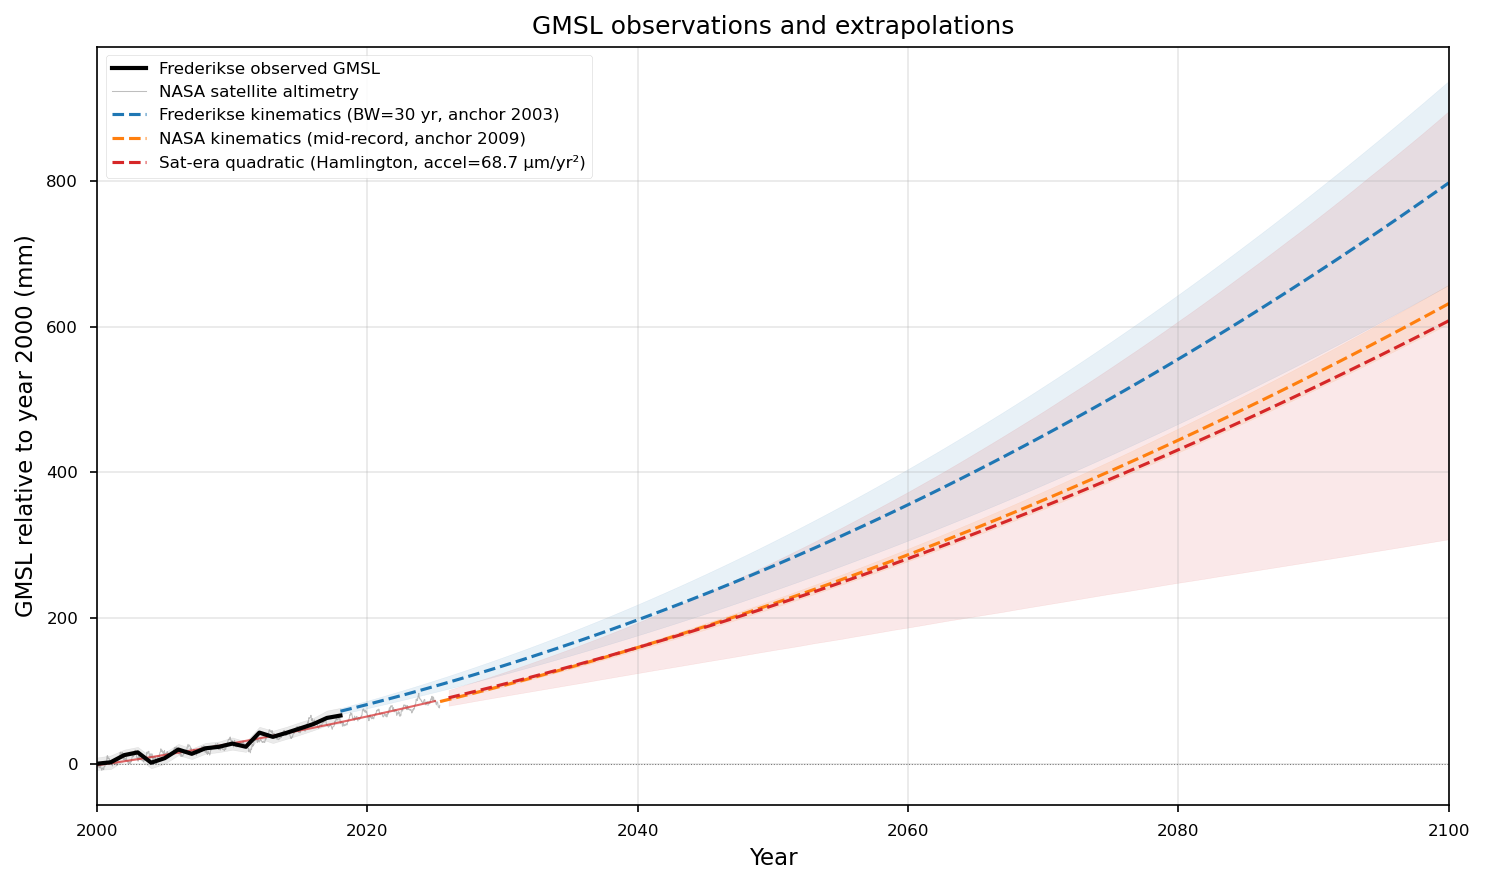

In [9]:
# ============================================================
# Comparison plot: observations + all extrapolation methods
# from year 2000 onward
# ============================================================

PLOT_START = 2000
PLOT_END = 2100

fig, ax = plt.subplots(figsize=(10, 6))

# --- Observed GMSL: Frederikse ---
mask_fred = fred_time >= PLOT_START
ax.plot(fred_time[mask_fred], fred_gmsl_rb[mask_fred] * M_TO_MM,
        'k-', lw=2, label='Frederikse observed GMSL', zorder=10)
ax.fill_between(fred_time[mask_fred],
                (fred_gmsl_rb[mask_fred] - 1.645 * fred_gmsl_sigma[mask_fred]) * M_TO_MM,
                (fred_gmsl_rb[mask_fred] + 1.645 * fred_gmsl_sigma[mask_fred]) * M_TO_MM,
                color='k', alpha=0.08)

# --- Observed GMSL: NASA satellite altimetry ---
mask_nasa = nasa_time >= PLOT_START
ax.plot(nasa_time[mask_nasa], nasa_gmsl_rb[mask_nasa] * M_TO_MM,
        color='C7', lw=0.5, alpha=0.5, label='NASA satellite altimetry')

# --- Frederikse kinematics extrapolation ---
mask_kin = t_extrap >= fred_time[-1]
ax.plot(t_extrap[mask_kin], quad_extrap[mask_kin] * M_TO_MM,
        '--', color='C0', lw=1.5,
        label=f'Frederikse kinematics (BW={EXTRAP_BW} yr, '
              f'anchor {t_end:.0f})')
ax.fill_between(t_extrap[mask_kin],
                quad_p5[mask_kin] * M_TO_MM,
                quad_p95[mask_kin] * M_TO_MM,
                color='C0', alpha=0.1)

# --- NASA mid-record kinematics extrapolation ---
mask_nasa_ext = nasa_extrap['time'] >= nasa_time[-1]
ax.plot(nasa_extrap['time'][mask_nasa_ext],
        nasa_extrap['gmsl'][mask_nasa_ext] * M_TO_MM,
        '--', color='C1', lw=1.5,
        label=f'NASA kinematics (mid-record, anchor {t_mid:.0f})')
ax.fill_between(nasa_extrap['time'][mask_nasa_ext],
                nasa_extrap['p5'][mask_nasa_ext] * M_TO_MM,
                nasa_extrap['p95'][mask_nasa_ext] * M_TO_MM,
                color='C1', alpha=0.1)

# --- Satellite-era quadratic fit (Hamlington method) ---
mask_sq_fit = (sat_quad_extrap['time'] >= PLOT_START) & (sat_quad_extrap['time'] <= nasa_time[-1])
mask_sq_ext = sat_quad_extrap['time'] >= nasa_time[-1]
# Fit portion (solid, thin)
ax.plot(sat_quad_extrap['time'][mask_sq_fit],
        sat_quad_extrap['gmsl'][mask_sq_fit] * M_TO_MM,
        '-', color='C3', lw=1, alpha=0.7)
# Extrapolation portion (dashed)
ax.plot(sat_quad_extrap['time'][mask_sq_ext],
        sat_quad_extrap['gmsl'][mask_sq_ext] * M_TO_MM,
        '--', color='C3', lw=1.5,
        label=f'Sat-era quadratic (Hamlington, '
              f'accel={sat_quad.accel*1e6:.1f} μm/yr²)')
ax.fill_between(sat_quad_extrap['time'][mask_sq_ext],
                sat_quad_extrap['p5'][mask_sq_ext] * M_TO_MM,
                sat_quad_extrap['p95'][mask_sq_ext] * M_TO_MM,
                color='C3', alpha=0.1)

# --- Formatting ---
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_xlabel('Year')
ax.set_ylabel('GMSL relative to year 2000 (mm)')
ax.set_title('GMSL observations and extrapolations')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.axhline(0, color='k', ls=':', lw=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)

# --- Summary table ---
print(f'{"Method":<40} {"2050 (mm)":>12} {"2075 (mm)":>12} {"2100 (mm)":>12}')
print('-' * 78)
for label, t_arr, g_arr in [
    ('Frederikse kinematics', t_extrap, quad_extrap),
    ('NASA mid-record kinematics', nasa_extrap['time'], nasa_extrap['gmsl']),
    ('Sat-era quadratic (Hamlington)', sat_quad_extrap['time'], sat_quad_extrap['gmsl']),
]:
    vals = [np.interp(yr, t_arr, g_arr) * M_TO_MM for yr in [2050, 2075, 2100]]
    print(f'{label:<40} {vals[0]:12.0f} {vals[1]:12.0f} {vals[2]:12.0f}')

plt.tight_layout()
plt.show()

## 4. Observed GMSL + GMST Twin-Axis Time Series

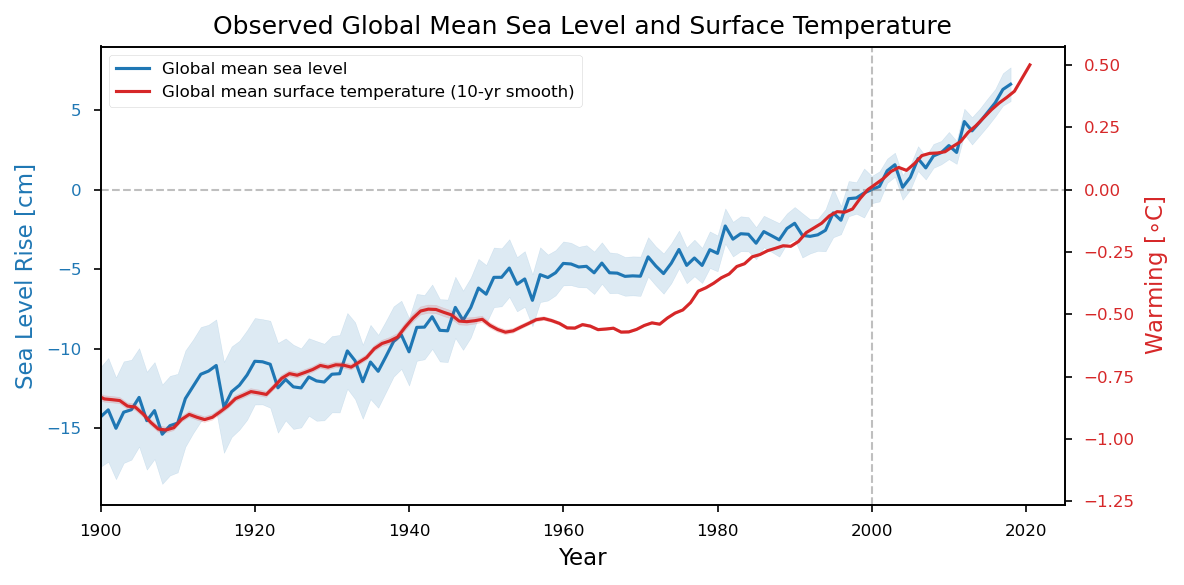

Figure 1 saved.


In [10]:
# ==============================================================
# Figure 1: Frederikse GMSL + Berkeley Earth GMST (20-yr smooth)
# ==============================================================

# ── Propagate GMST uncertainty through smoothing ──
# Step 1: monthly σ → annual σ  (independent months, quadrature)
temp_sigma_annual = (
    df_berkeley['temperature_sigma']
    .resample('YS').apply(lambda s: np.sqrt((s**2).sum()) / len(s))
)
temp_annual['temp_sigma'] = temp_sigma_annual.values

# Step 2: annual σ → smoothed σ  (rolling quadrature, same window as temp_smooth)
def rolling_sigma(sigma_col, window=10, min_periods=10):
    """Propagate independent annual σ through centered rolling mean."""
    n = len(sigma_col)
    sigma_smooth = np.full(n, np.nan)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half + 1)
        hi = min(n, i + half + 1)
        chunk = sigma_col.iloc[lo:hi].dropna()
        if len(chunk) >= min_periods:
            sigma_smooth[i] = np.sqrt((chunk**2).sum()) / len(chunk)
    return sigma_smooth

temp_annual['temp_smooth_sigma'] = rolling_sigma(temp_annual['temp_sigma'])

fig, ax1 = plt.subplots(figsize=(8, 4))

# GMSL on left y-axis
unit_convert = 100.
ax1.plot(fred_time, fred_gmsl_rb*unit_convert, color='tab:blue', linewidth=1.5,
         label='Global mean sea level')

#ax1.plot(horw_time, horw_gmsl_smooth*unit_convert, '-', color='tab:orange', linewidth=1.5)

ax1.fill_between(fred_time,
                 unit_convert*(fred_gmsl_rb - 1.645 * fred_gmsl_sigma),
                 unit_convert*(fred_gmsl_rb + 1.645 * fred_gmsl_sigma),
                 color='tab:blue', alpha=0.15)#, label='90% CI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sea Level Rise [cm]',
               color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
ax1.axvline(BASELINE_YEAR,color='gray', ls='--', lw=1, alpha=0.5)

# GMST on right y-axis
ax2 = ax1.twinx()
mask_smooth = temp_annual['temp_smooth_rb'].notna()
years_smooth = temp_annual['year'].values[mask_smooth]
temp_smooth_vals = temp_annual['temp_smooth_rb'].values[mask_smooth]
temp_smooth_sig = temp_annual['temp_smooth_sigma'].values[mask_smooth]

ax2.plot(years_smooth, temp_smooth_vals,
         color='tab:red', linewidth=1.5, linestyle='-',
         label='Global mean surface temperature (10-yr smooth)')
ax2.fill_between(years_smooth,
                 temp_smooth_vals - 1.645 * temp_smooth_sig,
                 temp_smooth_vals + 1.645 * temp_smooth_sig,
                 color='tab:red', alpha=0.15)
ax2.set_ylabel(r'Warming [$\circ$C]',
               color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9)

# Align y = 0 on both axes to the same horizontal position
sl_lo, sl_hi = ax1.get_ylim()
t_lo, t_hi = ax2.get_ylim()
# Fraction of zero from bottom for each axis
f_sl = -sl_lo / (sl_hi - sl_lo)
f_t  = -t_lo / (t_hi - t_lo)
# Expand the axis whose zero is closer to the bottom
if f_sl > f_t:
    # Push GMST lower limit down so its zero matches GMSL's
    new_t_lo = -f_sl / (1 - f_sl) * t_hi
    ax2.set_ylim(new_t_lo, t_hi)
else:
    # Push GMSL lower limit down so its zero matches GMST's
    new_sl_lo = -f_t / (1 - f_t) * sl_hi
    ax1.set_ylim(new_sl_lo, sl_hi)

ax1.set_xlim(1900, 2025)
ax1.set_title('Observed Global Mean Sea Level and Surface Temperature')
fig.tight_layout()
fig.savefig('../figures/playing_w_figures_fig1_observations.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 5. Two-Panel Projection Plot with Societal Impact Axes

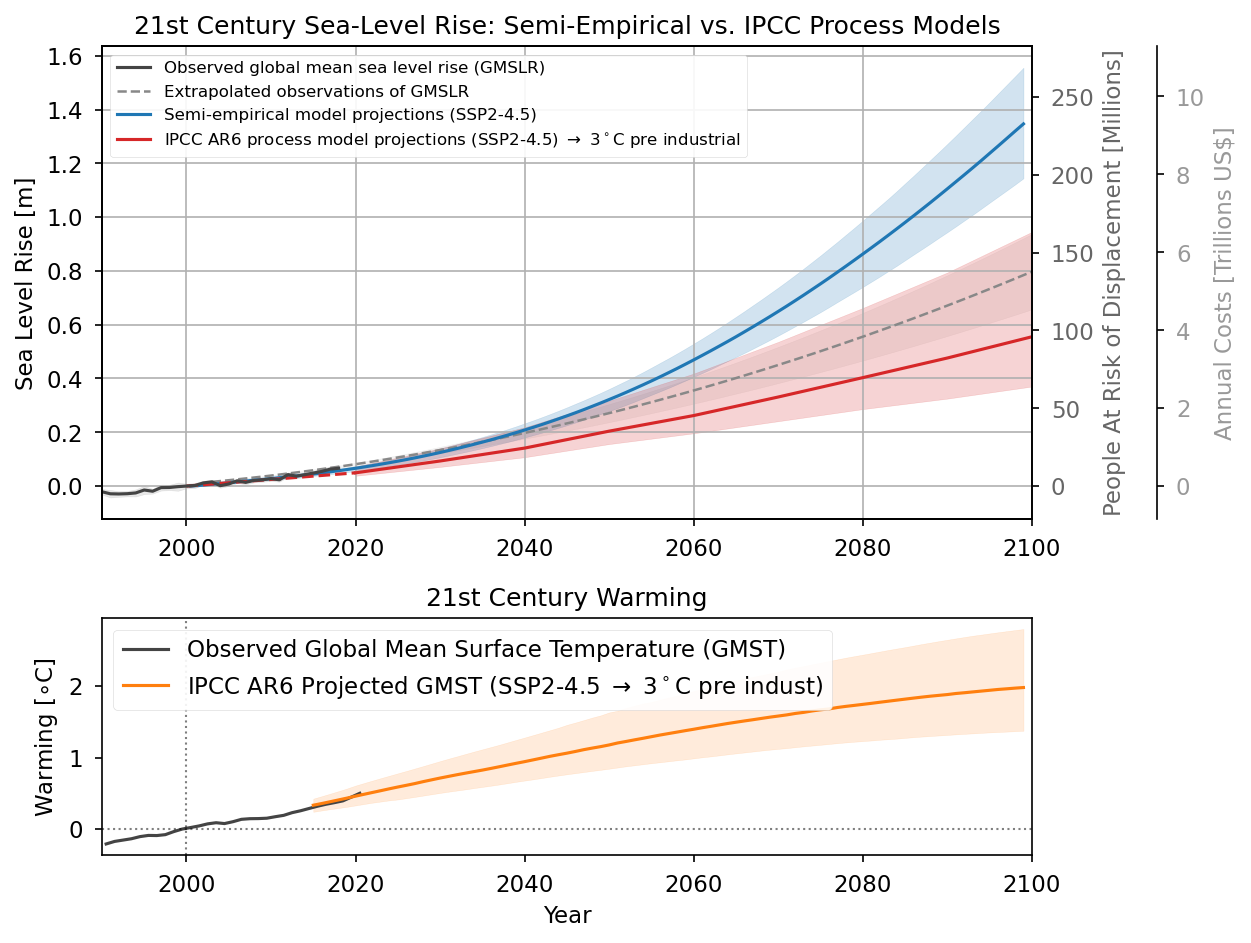

Figure 2 saved.


In [11]:
# ============================================================
# Figure 2: Two-panel projection plot
# Upper: GMSL projections + impact axes
# Lower: GMST observations + IPCC projections
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end = kin.rate[-1]
    rate_se_end = kin.rate_se[-1]
    accel_end = kin.accel[-1]
    accel_se_end = kin.accel_se[-1]
    t_end = kin.time[-1]
    H_end = fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )
    rng = np.random.default_rng(42)
    n_boot = 100000
    quad_boot = np.zeros((n_boot, len(t_extrap)))
    for k in range(n_boot):
        r_k = rng.normal(rate_end, rate_se_end)
        a_k = rng.normal(accel_end, accel_se_end)
        quad_boot[k] = np.where(
            t_extrap <= t_end,
            np.interp(t_extrap, fred_time, fred_gmsl_rb),
            H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
        )
    quad_p5 = np.percentile(quad_boot, 5, axis=0)
    quad_p95 = np.percentile(quad_boot, 95, axis=0)
    print(f'[auto-computed kinematics: rate={rate_end*M_TO_MM:.2f} mm/yr, '
          f'accel={accel_end*M_TO_MM:.4f} mm/yr²]')

# --- User-adjustable parameters ---
YEAR_START = 1990
YEAR_END = 2100
SSP = 'SSP2-4.5'
COLOR_OBS = '#444444'          # dark grey for observations
COLOR_EXTRAP = '#888888'       # lighter grey for extrapolation
COLOR_RS = 'tab:blue'          # Rate-and-state model
COLOR_IPCC = 'tab:red'         # IPCC process models
COLOR_GMST = 'tab:orange'      # GMST
ALPHA_CI = 0.2
SHOW_COMBINED = False           # toggle: overlay R&S + WAIS instability
SHOW_DOLS = True
SHOW_EXTRAP = True
SHOW_IPCC = True

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)

# ==================== UPPER PANEL: GMSL ====================
ax_sl = fig.add_subplot(gs[0])

GRID_ON = True
if not GRID_ON:
    ax_sl.axhline(0, color='k', ls=':', lw=1, alpha=0.5)
    ax_sl.axvline(BASELINE_YEAR,color='k', ls=':', lw=1, alpha=0.5)

# Frederikse observations
if not any([SHOW_DOLS, SHOW_COMBINED]):
    colorobs = COLOR_RS  ### make the extrapolation plot look nicer
else:
    colorobs = COLOR_OBS
    
mask_obs = (fred_time >= YEAR_START) & (fred_time <= YEAR_END)
ax_sl.plot(fred_time[mask_obs], fred_gmsl_rb[mask_obs],
           color=colorobs, linewidth=1.5, label='Observed global mean sea level rise (GMSLR)', zorder=10)
ax_sl.fill_between(fred_time[mask_obs],
                   fred_gmsl_rb[mask_obs] - 1.645 * fred_gmsl_sigma[mask_obs],
                   fred_gmsl_rb[mask_obs] + 1.645 * fred_gmsl_sigma[mask_obs],
                   color=colorobs, alpha=0.12)

if SHOW_EXTRAP:
    # Kinematics extrapolation (dashed, beyond end of data only)
    mask_ext = (t_extrap >= t_end) & (t_extrap <= YEAR_END)

    if not any([SHOW_DOLS, SHOW_COMBINED]):
        colorextrap = COLOR_RS  ### make the extrapolation plot look nicer
    else:
        colorextrap = COLOR_EXTRAP
        
    ax_sl.plot(t_extrap[mask_ext], quad_extrap[mask_ext],
               color=colorextrap, linewidth=1.2, linestyle='--',
               label='Extrapolated observations of GMSLR')
    ax_sl.fill_between(t_extrap[mask_ext], quad_p5[mask_ext], quad_p95[mask_ext],
                       color=colorextrap, alpha=0.1)

if SHOW_DOLS:
    # Rate-and-state posterior mean projection
    rs_df = mc_results['scenarios'][SSP]
    rs_time = rs_df['decimal_year'].values
    mask_rs = (rs_time >= YEAR_START) & (rs_time <= YEAR_END)
    ax_sl.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs],
               color=COLOR_RS, linewidth=1.5,
               label=f'Semi-empirical model projections ({SSP})')
    ax_sl.fill_between(rs_time[mask_rs],
                       rs_df['gmsl_lower'].values[mask_rs],
                       rs_df['gmsl_upper'].values[mask_rs],
                       color=COLOR_RS, alpha=ALPHA_CI)

# --- Combined R&S + WAIS instability projection ---
if SHOW_COMBINED and SSP in bamber_wais:
    proj_years = rs_time[mask_rs]
    n_proj = len(proj_years)
    rng_comb = np.random.default_rng(42)

    # Reconstruct R&S samples at all projection years
    rs_med_arr = rs_df['gmsl'].values[mask_rs]
    rs_lo_arr = rs_df['gmsl_lower'].values[mask_rs]
    rs_hi_arr = rs_df['gmsl_upper'].values[mask_rs]
    rs_sig_arr = (rs_hi_arr - rs_lo_arr) / (2 * 1.645)
    rs_ens = (rng_comb.normal(0, 1, (N_SAMPLES, n_proj))
              * rs_sig_arr + rs_med_arr)

    # WAIS samples at each projection year (0 before Bamber start year)
    rheology_multiplier = 2. # 
    bw = bamber_wais['SSP5-8.5']
    bw_start = bw['years'][0]
    wais_ens = np.zeros((N_SAMPLES, n_proj))
    for j, yr in enumerate(proj_years):
        if yr >= bw_start:
            idx_w = np.argmin(np.abs(bw['years'] - yr))
            wais_ens[:, j] = bw['samples'][:N_SAMPLES, idx_w] * rheology_multiplier

    combined_ens = rs_ens + wais_ens
    comb_med = np.median(combined_ens, axis=0)
    comb_lo = np.percentile(combined_ens, 5, axis=0)
    comb_hi = np.percentile(combined_ens, 95, axis=0)

    ax_sl.plot(proj_years, comb_med,
               color=COLOR_COMBINED, linewidth=1.5,
               label=f'Semi-empirical + WAIS instability ({SSP})')
    ax_sl.fill_between(proj_years, comb_lo, comb_hi,
                       color=COLOR_COMBINED, alpha=ALPHA_CI)

if SHOW_IPCC:
    # IPCC process-model projection
    ipcc_df = ipcc_gmsl_rb[SSP]
    ipcc_time = ipcc_df['decimal_year'].values
    mask_ipcc = (ipcc_time >= YEAR_START) & (ipcc_time <= 2100)
    ax_sl.plot(ipcc_time[mask_ipcc], ipcc_df['gmsl'].values[mask_ipcc],
               color=COLOR_IPCC, linewidth=1.5,
               label=f'IPCC AR6 process model projections ({SSP}) $\\rightarrow$ {map_ssp2temp[SSP]} pre industrial')
    ax_sl.fill_between(ipcc_time[mask_ipcc],
                       ipcc_df['gmsl_lower'].values[mask_ipcc],
                       ipcc_df['gmsl_upper'].values[mask_ipcc],
                       color=COLOR_IPCC, alpha=ALPHA_CI)
    
    # IPCC hindcast: dashed line from baseline (year 2000, 0) to first projection point
    ax_sl.plot([2000, ipcc_time[mask_ipcc][0]],
               [0.0, ipcc_df['gmsl'].values[mask_ipcc][0]],
               color=COLOR_IPCC, linewidth=1.5, linestyle='--')

if GRID_ON: 
    ax_sl.grid('on') 
    
ax_sl.tick_params(labelsize=11)
ax_sl.set_xlim(YEAR_START, YEAR_END)
ax_sl.set_ylabel('Sea Level Rise [m]')
ax_sl.legend(loc='upper left', fontsize=8, frameon=True, framealpha=0.9)
ax_sl.set_title(f'21st Century Sea-Level Rise: Semi-Empirical vs. IPCC Process Models')


# --- Right axis 1: Additional people exposed (elevation only, no defenses) (from Kulp & Strauss 2019) ---
# Linear scaling baselined to zero at SLR = 0 (baseline year),
# so impact axes read 0 at the baseline regardless of YEAR_START.
pop_baseline = people_displaced_kulpstrauss2019(0.0)
ax_pop = ax_sl.twinx()
sl_lo, sl_hi = ax_sl.get_ylim()
pop_at_hi = people_displaced_kulpstrauss2019(sl_hi) - pop_baseline
pop_scale = pop_at_hi / sl_hi if sl_hi > 0 else 0
ax_pop.set_ylim(pop_scale * sl_lo, pop_scale * sl_hi)
ax_pop.set_ylabel("People At Risk of Displacement [Millions]", color="#666666")
ax_pop.tick_params(axis='y', labelcolor='#666666')
ax_pop.spines['right'].set_position(('outward', 0))
ax_pop.tick_params(labelsize=11)

# --- Right axis 2: Annual flood cost (from Jevrejeva 2018) ---
ax_cost = ax_sl.twinx()
ax_cost.spines['right'].set_position(('outward', 60))
cost_at_hi = 0.45e-3 * slr_cost_jevrejeva2018(sl_hi)
cost_scale = cost_at_hi / sl_hi if sl_hi > 0 else 0
ax_cost.set_ylim(cost_scale * sl_lo, cost_scale * sl_hi)
ax_cost.set_ylabel('Annual Costs [Trillions US\\$]', color='#999999')
ax_cost.tick_params(axis='y', labelcolor='#999999')
ax_cost.tick_params(labelsize=11)

# ==================== LOWER PANEL: GMST ====================
ax_t = fig.add_subplot(gs[1], sharex=ax_sl)

# Observed 20-yr smoothed GMST
mask_ts = (temp_annual['year'].values >= YEAR_START) & \
          (temp_annual['year'].values <= YEAR_END) & \
          temp_annual['temp_smooth_rb'].notna()
ax_t.plot(temp_annual['year'].values[mask_ts],
          temp_annual['temp_smooth_rb'].values[mask_ts],
          color=COLOR_OBS, linewidth=1.5,
          label='Observed Global Mean Surface Temperature (GMST)')

# IPCC SSP temperature projection
tp_df = temp_proj_rb[SSP]
tp_time = tp_df['decimal_year'].values
mask_tp = (tp_time >= YEAR_START) & (tp_time <= YEAR_END)
ax_t.plot(tp_time[mask_tp], tp_df['temperature'].values[mask_tp],
          color=COLOR_GMST, linewidth=1.5, linestyle='-',
          label=f'IPCC AR6 Projected GMST ({SSP} $\\rightarrow$ {map_ssp2temp[SSP]} pre indust)')
if 'temperature_lower' in tp_df.columns:
    ax_t.fill_between(tp_time[mask_tp],
                      tp_df['temperature_lower'].values[mask_tp],
                      tp_df['temperature_upper'].values[mask_tp],
                      color=COLOR_GMST, alpha=0.15)

ax_t.axhline(0,linestyle=':',color='k',lw=1,alpha=0.5)
ax_t.axvline(2000,linestyle=':',color='k',lw=1,alpha=0.5)

ax_t.tick_params(labelsize=11)
ax_t.set_title(f"21st Century Warming")
ax_t.set_xlabel('Year')
ax_t.set_ylabel(r'Warming [$\circ$C]')
ax_t.legend(loc='upper left', fontsize=11, frameon=True, framealpha=0.9)

fig.savefig('../figures/playing_w_figures_fig2_projections.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 6. Histogram and Ridge Plot Variants of GMSL Projections

/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_61433/171328344.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=7, frameon=True, framealpha=0.9)


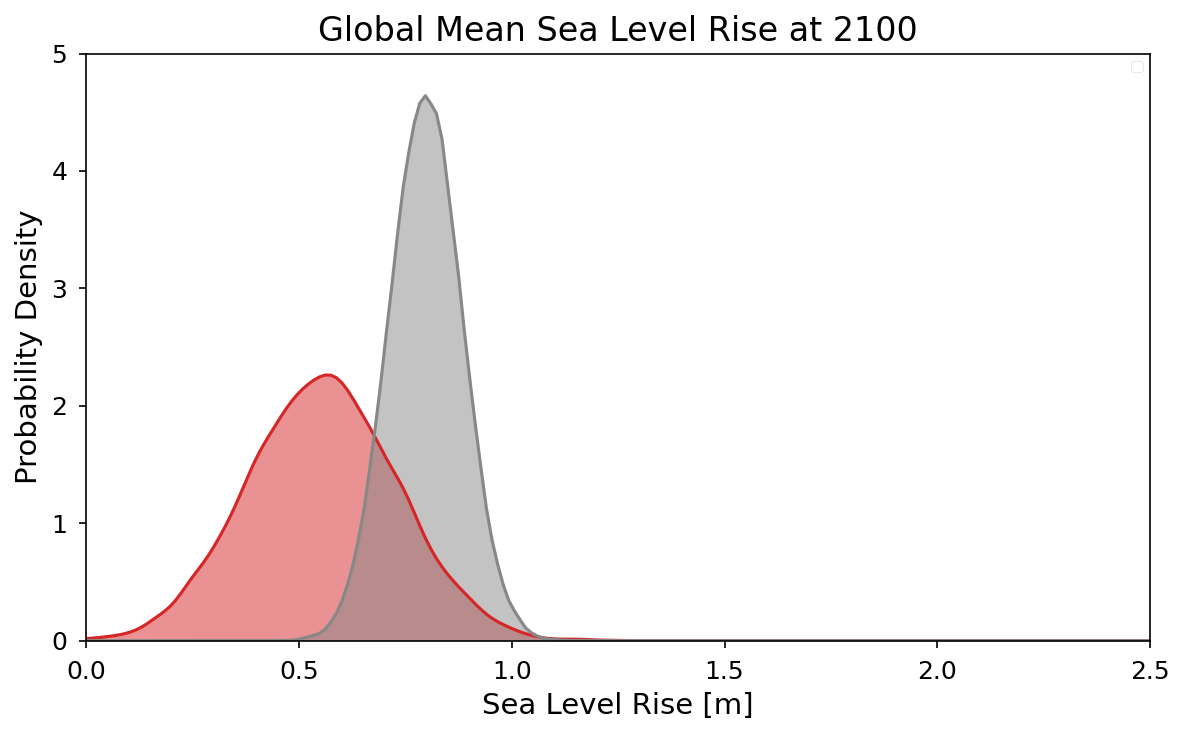

Figure 3 saved.


In [12]:
# ============================================================
# Figure 3: Histogram of GMSL at a single year
# Shows IPCC, extrapolated observations, and rate-and-state
# for a user-defined SSP. Same colors/labels as Figure 2.
# ============================================================
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d

# --- User-adjustable parameters ---
HIST_YEAR = 2100
HIST_SSP = 'SSP2-4.5'
SHOW_IMPACT_POP = False         # toggle population-exposed axis
SHOW_IMPACT_COST = False        # toggle cost axis
SHOW_COMBINED_3 = True         # toggle: add R&S + WAIS instability

# --- Reconstruct approximate samples at HIST_YEAR ---
# (projection functions store only summary statistics;
#  approximate samples via Gaussian from median & 5-95% CI)
n_kde = 10000
rng_hist = np.random.default_rng(99)

# 1. Rate-and-state
rs_df = mc_results['scenarios'][HIST_SSP]
idx_rs = np.argmin(np.abs(rs_df['decimal_year'].values - HIST_YEAR))
rs_med = rs_df['gmsl'].values[idx_rs]
rs_lo = rs_df['gmsl_lower'].values[idx_rs]
rs_hi = rs_df['gmsl_upper'].values[idx_rs]
rs_sigma = (rs_hi - rs_lo) / (2 * 1.645)
rs_samples = rng_hist.normal(rs_med, rs_sigma, n_kde)

# 2. IPCC process model
ipcc_df = ipcc_gmsl_rb[HIST_SSP]
idx_ipcc = np.argmin(np.abs(ipcc_df['decimal_year'].values - HIST_YEAR))
ipcc_med = ipcc_df['gmsl'].values[idx_ipcc]
ipcc_lo = ipcc_df['gmsl_lower'].values[idx_ipcc]
ipcc_hi = ipcc_df['gmsl_upper'].values[idx_ipcc]
ipcc_sigma = (ipcc_hi - ipcc_lo) / (2 * 1.645)
ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sigma, n_kde)

# 3. Extrapolated observations (use quad_boot ensemble directly)
idx_ext = np.argmin(np.abs(t_extrap - HIST_YEAR))
ext_samples = quad_boot[:, idx_ext]   # (n_boot,) in meters

# 4. Combined R&S + WAIS instability
comb_samples = None
if SHOW_COMBINED_3:
    comb_samples, _, _ = get_combined_samples(
        HIST_SSP, HIST_YEAR, n_samples=n_kde, seed=99)

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 5))

all_sample_sets = [ext_samples, rs_samples, ipcc_samples]
if comb_samples is not None:
    all_sample_sets.append(comb_samples)

bins = np.linspace(
    min(s.min() for s in all_sample_sets) - 0.02,
    max(s.max() for s in all_sample_sets) + 0.02,
    60,
)

'''
ax.hist(ext_samples, bins=bins, density=True, alpha=0.35,
        color=COLOR_EXTRAP, edgecolor='none',
        label='Extrapolated observations of GMSLR')
ax.hist(rs_samples, bins=bins, density=True, alpha=0.35,
        color=COLOR_RS, edgecolor='none',
        label=f'Semi-empirical model projections ({HIST_SSP})')
ax.hist(ipcc_samples, bins=bins, density=True, alpha=0.35,
        color=COLOR_IPCC, edgecolor='none',
        label=f'IPCC AR6 process model projections ({HIST_SSP})')
if comb_samples is not None:
    ax.hist(comb_samples, bins=bins, density=True, alpha=0.35,
            color=COLOR_COMBINED, edgecolor='none',
            label=f'Semi-empirical + WAIS instability ({HIST_SSP})')
'''

# KDE overlay lines
kde_pairs = [(ext_samples, COLOR_EXTRAP),
             (rs_samples, COLOR_RS),
             (ipcc_samples, COLOR_IPCC)]

if comb_samples is not None:
    kde_pairs.append((comb_samples, COLOR_COMBINED))

#kde_pairs = [(ipcc_samples, COLOR_IPCC)]
kde_pairs = [(ipcc_samples, COLOR_IPCC), (ext_samples, COLOR_EXTRAP)]

for samples, color in kde_pairs:
    kde = gaussian_kde(samples)
    x_kde = np.linspace(bins[0], bins[-1], 300)
    ax.fill_between(x_kde,0,kde(x_kde), color=color, alpha=0.5)
    ax.plot(x_kde, kde(x_kde), color=color, lw=1.5)

# Median lines
for val, color, ls in [(np.median(ext_samples), COLOR_EXTRAP, '--'),
                       (rs_med, COLOR_RS, '-'),
                       (ipcc_med, COLOR_IPCC, '-')]:
    #ax.axvline(val, color=color, ls=ls, lw=1.2, alpha=0.7)
    continue

ax.set_xlim(0, 2.5)
ax.set_ylim(bottom=0, top=5)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax.set_xlabel('Sea Level Rise [m]',fontsize=14)
ax.set_ylabel('Probability Density',fontsize=14)
ax.set_title(f'Global Mean Sea Level Rise at {HIST_YEAR}',fontsize=16)
ax.legend(loc='upper right', fontsize=7, frameon=True, framealpha=0.9)

# --- Helper: choose step size that yields ~5-8 ticks ---
def _nice_step(val_range, base_unit, target_nticks=6):
    raw_step = val_range / target_nticks
    step = max(base_unit, np.round(raw_step / base_unit) * base_unit)
    return step

# --- Impact axes (derived from main axis limits, not hard-coded) ---
sl_lo, sl_hi = ax.get_xlim()
slr_test = np.linspace(sl_lo, sl_hi, 2000)

if SHOW_IMPACT_POP:
    ax_pop = ax.twiny()
    pop_baseline = people_displaced_kulpstrauss2019(0.0)
    pop_test = np.array([people_displaced_kulpstrauss2019(v) - pop_baseline
                         for v in slr_test])
    # Inverse mapping: population -> SLR (multiples of 10)
    pop_to_slr = interp1d(pop_test, slr_test, bounds_error=False,
                           fill_value='extrapolate')
    pop_max = pop_test.max()
    pop_step = _nice_step(pop_max, base_unit=10)
    pop_targets = np.arange(0, pop_max + pop_step, pop_step)
    pop_targets = pop_targets[pop_targets <= pop_max * 1.05]
    pop_tick_slr = pop_to_slr(pop_targets)
    # Filter to within x-range
    mask = (pop_tick_slr >= sl_lo) & (pop_tick_slr <= sl_hi)
    pop_tick_slr = pop_tick_slr[mask]
    pop_targets = pop_targets[mask]

    ax_pop.set_xlim(sl_lo, sl_hi)
    ax_pop.set_xticks(pop_tick_slr)
    ax_pop.set_xticklabels([f'{int(v)}' for v in pop_targets],
                           color='#666666', fontsize=8)
    ax_pop.set_xlabel('People At Risk of Displacement [Millions]',
                      color='#666666', fontsize=9)

if SHOW_IMPACT_COST:
    ax_cost = ax.twiny()
    ax_cost.spines['top'].set_position(('outward', 36))
    cost_test = np.array([0.45e-3 * slr_cost_jevrejeva2018(v)
                          for v in slr_test])
    # Inverse mapping: cost -> SLR (integer trillions)
    cost_to_slr = interp1d(cost_test, slr_test, bounds_error=False,
                            fill_value='extrapolate')
    cost_max = cost_test.max()
    # Skip 2 -- falls in steep segment of piecewise cost function
    cost_targets = np.array([0] + list(np.arange(4, cost_max + 2, 2)))
    cost_targets = cost_targets[cost_targets <= cost_max * 1.05]
    cost_tick_slr = cost_to_slr(cost_targets)
    # Filter to within x-range
    mask = (cost_tick_slr >= sl_lo) & (cost_tick_slr <= sl_hi)
    cost_tick_slr = cost_tick_slr[mask]
    cost_targets = cost_targets[mask]

    ax_cost.set_xlim(sl_lo, sl_hi)
    ax_cost.set_xticks(cost_tick_slr)
    ax_cost.set_xticklabels([f'{int(v)}' for v in cost_targets],
                            color='#999999', fontsize=8)
    ax_cost.set_xlabel('Annual Costs [Trillions US\\$]',
                       color='#999999', fontsize=9)

fig.tight_layout()
fig.savefig(f'../figures/playing_w_figures_fig3_histogram_single_{HIST_YEAR}_{HIST_SSP}_ipcc_obs.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

got bamber
got bamber
got bamber


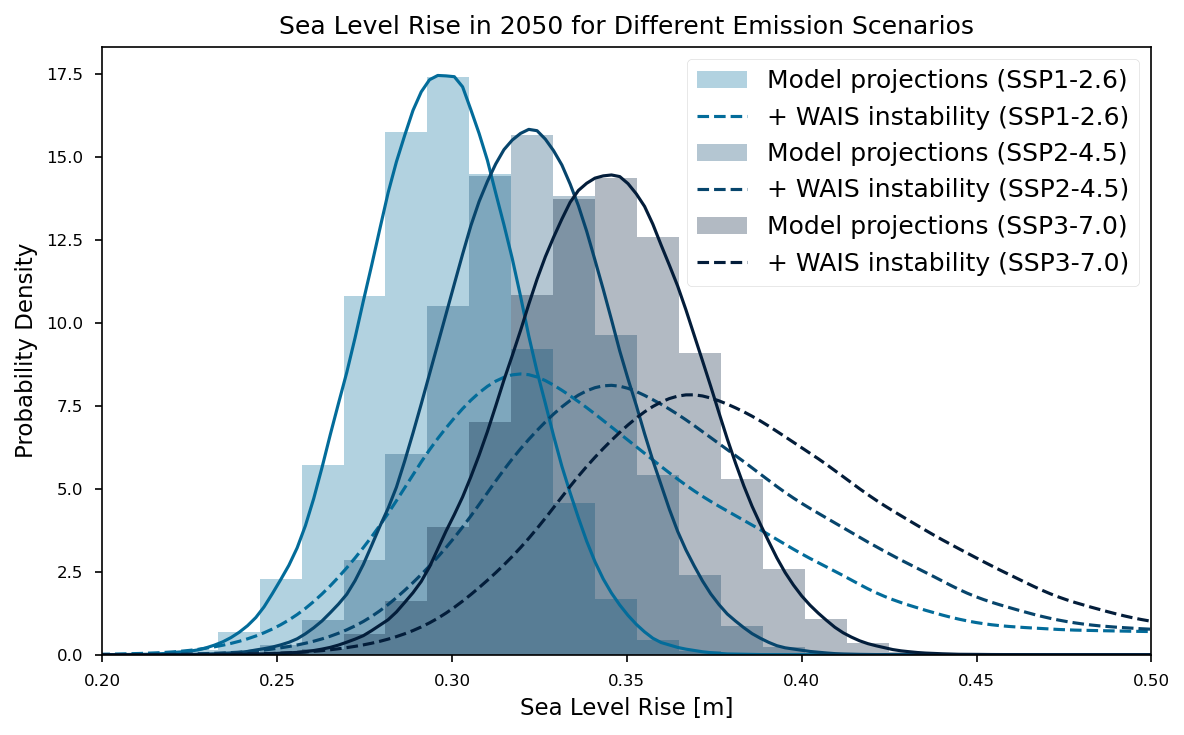

Figure 4 saved.


In [13]:
# ============================================================
# Figure 4: Histogram of GMSL — rate-and-state for three SSPs
# Same colors/labels/style as Figure 2.
# ============================================================

# --- User-adjustable parameters ---
HIST4_YEAR = 2050
HIST4_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']
SHOW_IMPACT_POP_4 = False
SHOW_IMPACT_COST_4 = False
SHOW_COMBINED_4 = True         # toggle: add R&S + WAIS instability

# SSP color scheme (consistent with Figure 2 projection panels)
SSP_COLORS = {
    'SSP1-2.6': arete_colors['blues'][3], #'#2166ac',   # blue
    'SSP2-4.5': arete_colors['blues'][4],  # same as COLOR_RS in Figure 2
    'SSP3-7.0': arete_colors['blues'][5],   # red
    'SSP5-8.5': arete_colors['blues'][-1],   # dark red
}

# --- Reconstruct approximate samples ---
n_kde4 = 250000
rng4 = np.random.default_rng(101)
ssp_samples = {}
ssp_medians = {}
ssp_comb_samples = {}

for ssp in HIST4_SSPS:
    rs_df = mc_results['scenarios'][ssp]
    idx_yr = np.argmin(np.abs(rs_df['decimal_year'].values - HIST4_YEAR))
    med = rs_df['gmsl'].values[idx_yr]
    lo = rs_df['gmsl_lower'].values[idx_yr]
    hi = rs_df['gmsl_upper'].values[idx_yr]
    sig = (hi - lo) / (2 * 1.645)
    ssp_samples[ssp] = rng4.normal(med, sig, n_kde4)
    ssp_medians[ssp] = med

    # Combined R&S + WAIS
    if SHOW_COMBINED_4:
        comb, _, _ = get_combined_samples(
            ssp, HIST4_YEAR, n_samples=n_kde4, seed=101)
        ssp_comb_samples[ssp] = comb
        print('got bamber')

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 5))

all_vals = np.concatenate(list(ssp_samples.values()))
if ssp_comb_samples:
    all_vals = np.concatenate([all_vals]
                              + list(ssp_comb_samples.values()))
bins = np.linspace(all_vals.min() - 0.02, all_vals.max() + 0.02, 60)

for ssp in HIST4_SSPS:
    color = SSP_COLORS[ssp]
    ax.hist(ssp_samples[ssp], bins=bins, density=True, alpha=0.3,
            color=color, edgecolor='none',
            label=f'Model projections ({ssp})')
    kde = gaussian_kde(ssp_samples[ssp])
    x_kde = np.linspace(bins[0], bins[-1], 300)
    ax.plot(x_kde, kde(x_kde), color=color, lw=1.5)

    # Combined overlay (dashed KDE to distinguish)
    if ssp in ssp_comb_samples:
        kde_c = gaussian_kde(ssp_comb_samples[ssp])
        ax.plot(x_kde, kde_c(x_kde), color=color, lw=1.5,
                ls='--', label=f'+ WAIS instability ({ssp})')

ax.set_xlim([0.2,0.5])
ax.set_xlabel('Sea Level Rise [m]')
ax.set_ylabel('Probability Density')
ax.set_title(f'Sea Level Rise in {HIST4_YEAR} for Different Emission Scenarios')
ax.legend(loc='upper right', fontsize=12, frameon=True, framealpha=0.9)

# --- Impact axes ---
if SHOW_IMPACT_POP_4:
    ax_pop = ax.twiny()
    sl_lo, sl_hi = ax.get_xlim()
    pop_baseline = people_displaced_kulpstrauss2019(0.0)
    pop_ticks_m = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    pop_ticks_m = pop_ticks_m[(pop_ticks_m >= sl_lo) & (pop_ticks_m <= sl_hi)]
    pop_labels = [f'{people_displaced_kulpstrauss2019(v) - pop_baseline:.0f}'
                  for v in pop_ticks_m]
    ax_pop.set_xlim(ax.get_xlim())
    ax_pop.set_xticks(pop_ticks_m)
    ax_pop.set_xticklabels(pop_labels, color='#666666', fontsize=8)
    ax_pop.set_xlabel('People At Risk of Displacement [Millions]',
                      color='#666666', fontsize=9)

if SHOW_IMPACT_COST_4:
    ax_cost = ax.twiny()
    ax_cost.spines['top'].set_position(('outward', 36))
    sl_lo, sl_hi = ax.get_xlim()
    cost_ticks_m = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    cost_ticks_m = cost_ticks_m[(cost_ticks_m >= sl_lo) & (cost_ticks_m <= sl_hi)]
    cost_labels = [f'{0.45e-3 * slr_cost_jevrejeva2018(v):.1f}'
                   for v in cost_ticks_m]
    ax_cost.set_xlim(ax.get_xlim())
    ax_cost.set_xticks(cost_ticks_m)
    ax_cost.set_xticklabels(cost_labels, color='#999999', fontsize=8)
    ax_cost.set_xlabel('Annual Costs [Trillions US\\$]',
                       color='#999999', fontsize=9)

fig.tight_layout()
fig.savefig(f'../figures/playing_w_figures_fig4_histogram_multi_ssp_{HIST4_YEAR}.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [14]:
# ============================================================
# Figure 5 — Distribution Computation + JSON Export
# Computes MC samples for each source × decade, stores to JSON.
# Run this cell once; then use the plotting cell(s) below freely.
# ============================================================
import json as _json
from matplotlib.colors import to_hex

# --- User-adjustable parameters ---
RIDGE_YEARS = np.arange(2030, 2110, 10)   # 2030-2100, 10-yr steps
RIDGE_SSP = 'SSP2-4.5'
SHOW_COMBINED_5 = True         # include R&S + WAIS instability source
N_RIDGE = 300000                # MC sample size per source per year
BW_FACTOR = 0.9                # KDE bandwidth factor (Scott × BW_FACTOR)
RIDGE_SEED = 202

# --- Source labels (matching Figure 2 conventions) ---
LBL_RS = f'Semi-empirical model projections ({RIDGE_SSP})'
LBL_IPCC = f'IPCC AR6 process model projections ({RIDGE_SSP})'
LBL_EXTRAP = 'Extrapolated observations of GMSLR'
LBL_COMBINED = f'Semi-empirical + WAIS instability ({RIDGE_SSP})'

source_palette = {
    LBL_EXTRAP: COLOR_EXTRAP,
    LBL_RS: COLOR_RS,
    LBL_IPCC: COLOR_IPCC,
    LBL_COMBINED: COLOR_COMBINED,
}

# --- Build per-year sample arrays ---
rng_ridge = np.random.default_rng(RIDGE_SEED)

year_samples = {}  # {yr: {source_label: array}}
for yr in RIDGE_YEARS:
    year_samples[yr] = {}

    # Rate-and-state (Gaussian approximation from summary stats)
    rs_df = mc_results['scenarios'][RIDGE_SSP]
    idx = np.argmin(np.abs(rs_df['decimal_year'].values - yr))
    med = rs_df['gmsl'].values[idx]
    lo = rs_df['gmsl_lower'].values[idx]
    hi = rs_df['gmsl_upper'].values[idx]
    sig = (hi - lo) / (2 * 1.645)
    year_samples[yr][LBL_RS] = rng_ridge.normal(med, sig, N_RIDGE)

    # IPCC
    ipcc_df = ipcc_gmsl_rb[RIDGE_SSP]
    idx_i = np.argmin(np.abs(ipcc_df['decimal_year'].values - yr))
    if abs(ipcc_df['decimal_year'].values[idx_i] - yr) < 3:
        med_i = ipcc_df['gmsl'].values[idx_i]
        lo_i = ipcc_df['gmsl_lower'].values[idx_i]
        hi_i = ipcc_df['gmsl_upper'].values[idx_i]
        sig_i = (hi_i - lo_i) / (2 * 1.645)
        year_samples[yr][LBL_IPCC] = rng_ridge.normal(med_i, sig_i, N_RIDGE)

    # Extrapolated observations
    idx_e = np.argmin(np.abs(t_extrap - yr))
    if idx_e < quad_boot.shape[1]:
        boot_vals = quad_boot[:, idx_e]
        year_samples[yr][LBL_EXTRAP] = rng_ridge.choice(boot_vals, N_RIDGE,
                                                         replace=True)

    # Combined R&S + WAIS instability
    if SHOW_COMBINED_5:
        comb, _, _ = get_combined_samples(
            RIDGE_SSP, yr, n_samples=N_RIDGE, seed=RIDGE_SEED,
            rheology_multiplier=2.0)
        year_samples[yr][LBL_COMBINED] = comb

# --- Global x-range across all years and sources ---
all_vals = np.concatenate([v for yr in year_samples
                           for v in year_samples[yr].values()])
x_lo = float(np.percentile(all_vals, 0.1)) - 0.02
x_hi = float(np.percentile(all_vals, 99.9)) + 0.02

# --- Build ridge_distributions dict ---
# Convert palette colors to hex for JSON serialization
palette_hex = {lbl: to_hex(c) for lbl, c in source_palette.items()}

# Source list (ordered for draw order)
sources_list = [LBL_COMBINED, LBL_EXTRAP, LBL_IPCC, LBL_RS]
sources_list = [s for s in sources_list if any(s in year_samples[yr] for yr in RIDGE_YEARS)]

# Build year_samples dict (lists for JSON) + summary stats
year_samples_json = {}
summary = {}
for yr in RIDGE_YEARS:
    yr_key = str(int(yr))
    year_samples_json[yr_key] = {}
    summary[yr_key] = {}
    for src, vals in year_samples[yr].items():
        year_samples_json[yr_key][src] = vals.tolist()
        summary[yr_key][src] = {
            'median': float(np.median(vals)),
            'p5': float(np.percentile(vals, 5)),
            'p95': float(np.percentile(vals, 95)),
        }

ridge_distributions = {
    'config': {
        'ssp': RIDGE_SSP,
        'years': [int(y) for y in RIDGE_YEARS],
        'n_samples': N_RIDGE,
        'bw_factor': BW_FACTOR,
        'seed': RIDGE_SEED,
        'show_combined': SHOW_COMBINED_5,
    },
    'x_range': {'x_lo': x_lo, 'x_hi': x_hi},
    'sources': sources_list,
    'source_palette': palette_hex,
    'year_samples': year_samples_json,
    'summary': summary,
}

# --- Write to JSON ---
ridge_json_path = '../data/processed/ridge_distributions.json'
with open(ridge_json_path, 'w') as f:
    _json.dump(ridge_distributions, f)
print(f'Wrote ridge_distributions to {ridge_json_path}')
print(f'  File size: {os.path.getsize(ridge_json_path) / 1e6:.1f} MB')

# --- Print summary table ---
print(f'\nRidge distributions for {RIDGE_SSP}  (N={N_RIDGE}, bw_factor={BW_FACTOR})')
print(f'{"Year":>6}', end='')
for src in sources_list:
    short = src.split('(')[0].strip()[:25]
    print(f'  {short:>28}', end='')
print()
for yr in RIDGE_YEARS:
    yr_key = str(int(yr))
    print(f'{int(yr):>6}', end='')
    for src in sources_list:
        if src in summary[yr_key]:
            s = summary[yr_key][src]
            print(f"  {s['median']:7.3f} [{s['p5']:6.3f}, {s['p95']:6.3f}]", end='')
        else:
            print(f"  {'—':>28}", end='')
    print()

Wrote ridge_distributions to ../data/processed/ridge_distributions.json
  File size: 194.4 MB

Ridge distributions for SSP2-4.5  (N=300000, bw_factor=0.9)
  Year     Semi-empirical + WAIS ins     Extrapolated observations     IPCC AR6 process model pr     Semi-empirical model proj
  2030    0.150 [ 0.100,  0.266]    0.134 [ 0.122,  0.146]    0.093 [ 0.059,  0.128]    0.125 [ 0.109,  0.141]
  2040    0.253 [ 0.171,  0.491]    0.197 [ 0.176,  0.219]    0.141 [ 0.086,  0.197]    0.208 [ 0.182,  0.235]
  2050    0.398 [ 0.292,  0.759]    0.271 [ 0.238,  0.305]    0.204 [ 0.124,  0.284]    0.322 [ 0.281,  0.363]
  2060    0.601 [ 0.435,  1.053]    0.356 [ 0.306,  0.404]    0.262 [ 0.152,  0.373]    0.469 [ 0.407,  0.531]
  2070    0.839 [ 0.589,  1.435]    0.450 [ 0.383,  0.518]    0.331 [ 0.184,  0.479]    0.650 [ 0.560,  0.739]
  2080    1.108 [ 0.764,  1.970]    0.555 [ 0.466,  0.644]    0.403 [ 0.215,  0.591]    0.863 [ 0.740,  0.986]
  2090    1.408 [ 0.964,  2.567]    0.671 [ 0.558,  

In [15]:
# ============================================================
# Figure 5 — KDE Precomputation
# Evaluates KDEs on a common grid so the plotting cell is instant.
# Re-run this cell to change bw_factor or grid resolution.
# ============================================================
import json as _json

# --- Load distributions (in-memory or from JSON) ---
if 'ridge_distributions' not in dir():
    _ridge_json_path = '../data/processed/ridge_distributions.json'
    with open(_ridge_json_path) as _f:
        ridge_distributions = _json.load(_f)
    print(f'Loaded ridge_distributions from {_ridge_json_path}')

_cfg = ridge_distributions['config']
_years = _cfg['years']
_bw_factor = _cfg['bw_factor']
_x_lo = ridge_distributions['x_range']['x_lo']
_x_hi = ridge_distributions['x_range']['x_hi']
_sources = ridge_distributions['sources']
_palette = ridge_distributions['source_palette']
_year_samples = ridge_distributions['year_samples']

# --- KDE evaluation grid ---
ridge_x_grid = np.linspace(_x_lo, _x_hi, 400)

# --- Precompute all KDE densities ---
ridge_kde = {}  # {yr_key: {src: density_array}}
for yr in _years:
    yr_key = str(yr)
    ridge_kde[yr_key] = {}
    for src in _sources:
        if src not in _year_samples[yr_key]:
            continue
        vals = np.asarray(_year_samples[yr_key][src])
        kde = gaussian_kde(vals, bw_method='scott')
        kde.set_bandwidth(kde.factor * _bw_factor)
        ridge_kde[yr_key][src] = kde(ridge_x_grid)

print(f'KDE precomputation done: {len(_years)} years × {len(_sources)} sources, '
      f'bw_factor={_bw_factor}, grid={len(ridge_x_grid)} pts')

KDE precomputation done: 8 years × 4 sources, bw_factor=0.9, grid=400 pts


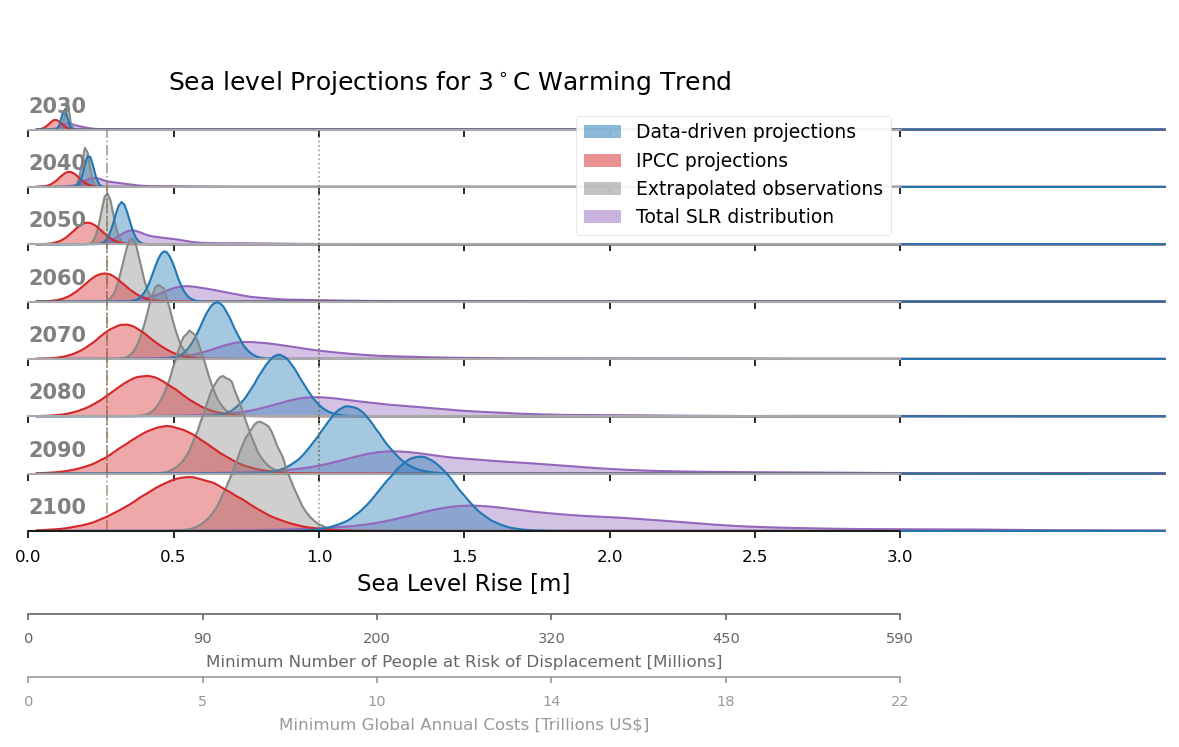

Figure 5 saved.


In [16]:
# ============================================================
# Figure 5: Ridge plot — IPCC + obs extrap + rate-and-state
# Plotting only — uses precomputed KDEs from the cell above.
# ============================================================
from matplotlib.patches import Patch
from scipy.interpolate import interp1d

_cfg = ridge_distributions['config']
_years = _cfg['years']
_ssp = _cfg['ssp']
_x_hi = 3. #ridge_distributions['x_range']['x_hi']
_all_sources = ridge_distributions['sources']   # all available
_palette = ridge_distributions['source_palette']

# =============================================================
# USER SWITCHES — toggle which distributions to show
# =============================================================
SHOW_RS       = True    # Semi-empirical (rate-and-state) model
SHOW_IPCC     = True    # IPCC AR6 process models
SHOW_EXTRAP   = True    # Extrapolated observations
SHOW_COMBINED = True    # Semi-empirical + WAIS instability
SHOW_HOLOCENE = True     # Common-era GMSL band (Clark et al. 2024)

# Map internal source keys → display toggle
_source_toggles = {}
for s in _all_sources:
    if 'Semi-empirical + WAIS' in s:
        _source_toggles[s] = SHOW_COMBINED
    elif 'Semi-empirical' in s:
        _source_toggles[s] = SHOW_RS
    elif 'IPCC' in s:
        _source_toggles[s] = SHOW_IPCC
    elif 'Extrapolated' in s:
        _source_toggles[s] = SHOW_EXTRAP
    else:
        _source_toggles[s] = True  # unknown source: show by default

# =============================================================
# USER LEGEND LABELS — override the long internal names
# Set to None to use the internal label as-is.
# =============================================================

LEGEND_LABELS = {}
for s in _all_sources:
    if 'Semi-empirical + WAIS' in s:
        LEGEND_LABELS[s] = 'Total SLR distribution'
    elif 'Semi-empirical' in s:
        LEGEND_LABELS[s] = 'Data-driven projections'
    elif 'IPCC' in s:
        LEGEND_LABELS[s] = 'IPCC projections'
    elif 'Extrapolated' in s:
        LEGEND_LABELS[s] = 'Extrapolated observations'
    else:
        LEGEND_LABELS[s] = s  # fallback

# =============================================================
# HOLOCENE GMSL REFERENCE (Clark et al., 2024, Nature Communications)
# Peak Holocene GMSL at ~3 ka, relative to ~2000 CE reference.
# Projections use a 2005 baseline ≈ 2000 CE for this purpose.
# =============================================================
HOLOCENE_MEDIAN = 0.27   # median peak Holocene GMSL [m above ~2000 CE]
HOLOCENE_P05    = -3.1   # 5th percentile (90% CI lower bound)
HOLOCENE_P95    = 1.0    # 95th percentile (90% CI upper bound)
HOLOCENE_COLOR  = '#8B7355'  # muted brown

# =============================================================
# OTHER PLOT PARAMETERS
# =============================================================
X_LIM = (0, _x_hi)             # x-axis range [m]; impact axes match this
PERSPECTIVE_ALPHA_5 = 0.25
SHOW_IMPACT_POP_5 = True
SHOW_IMPACT_COST_5 = True

# --- Active sources (filtered by toggles, preserving draw order) ---
_active_sources = [s for s in _all_sources if _source_toggles.get(s, True)]

# --- Figure: overlapping ridge plot ---
n_yrs5 = len(_years)
row_height = 0.5
fig, axes = plt.subplots(n_yrs5, 1,
                         figsize=(15 * row_height, n_yrs5 * row_height),
                         sharex=True)
if n_yrs5 == 1:
    axes = [axes]

for i, yr in enumerate(_years):
    yr_key = str(yr)
    ax = axes[i]
    ax.set_facecolor((0, 0, 0, 0))

    for src in _active_sources:
        if src not in ridge_kde[yr_key]:
            continue
        density = ridge_kde[yr_key][src]
        color = _palette[src]
        ax.fill_between(ridge_x_grid, density, alpha=0.4, color=color,
                        clip_on=False)
        ax.plot(ridge_x_grid, density, color=color, lw=1.0, clip_on=False)

    ax.axhline(0, color='darkgrey', lw=1, clip_on=False)
    ax.text(0.0, 0.2, str(yr), fontweight='bold', color='0.5',
            ha='left', va='center', transform=ax.transAxes)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_ylim(bottom=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

# --- Perspective scaling ---
for i, ax in enumerate(axes):
    p = i / max(n_yrs5 - 1, 1)
    perspective = PERSPECTIVE_ALPHA_5 + (1.0 - PERSPECTIVE_ALPHA_5) * p
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax / perspective)

# --- Holocene GMSL reference band (spans all panels) ---
if SHOW_HOLOCENE:
    for ax in axes[2:]:#[1:-1:2]:
        #ax.axvspan(max(HOLOCENE_P05, X_LIM[0]), min(HOLOCENE_P95, X_LIM[1]),
        #           color=HOLOCENE_COLOR, alpha=0.10, zorder=0, clip_on=True)
        ax.axvline(HOLOCENE_MEDIAN, color=HOLOCENE_COLOR, lw=0.8,
                   ls='-.', alpha=0.7, zorder=0, clip_on=True)
        ax.axvline(HOLOCENE_P95, color=HOLOCENE_COLOR, lw=0.8,
                   ls=':', alpha=0.7, zorder=0, clip_on=True)

# Bottom axis
axes[-1].spines['bottom'].set_visible(True)
axes[-1].set_xlabel('Sea Level Rise [m]')
axes[-1].set_xlim(*X_LIM)

# Legend in second panel (front-to-back order, using custom labels)
legend_order = list(reversed(_active_sources))
legend_handles = [Patch(facecolor=_palette[s], alpha=0.5,
                        label=LEGEND_LABELS.get(s, s))
                  for s in legend_order if s in _palette]
#if SHOW_HOLOCENE:
#    legend_handles.append(Patch(facecolor=HOLOCENE_COLOR, alpha=0.15,
#                                label='Sea level in common era'))
axes[2].legend(handles=legend_handles, loc='lower right', fontsize=9,
               frameon=True, framealpha=0.9)

fig.subplots_adjust(hspace=-0.5, bottom=0.06, top=0.92)
fig.suptitle(f'Sea level Projections for {map_ssp2temp[_ssp]} Warming Trend',
             fontsize=12, y=0.83)

# --- Impact axes on the BOTTOM panel ---
# Dense SLR sample spanning the full user-defined X_LIM
slr_test = np.linspace(X_LIM[0], X_LIM[1], 2000)

def _nice_step(val_range, base_unit, target_nticks=6):
    """Return a multiple of base_unit that gives ~target_nticks ticks."""
    raw_step = val_range / target_nticks
    step = max(base_unit, np.round(raw_step / base_unit) * base_unit)
    return step

if SHOW_IMPACT_POP_5:
    ax_pop = axes[-1].twiny()
    ax_pop.xaxis.set_ticks_position('bottom')
    ax_pop.xaxis.set_label_position('bottom')
    for sp in ax_pop.spines.values():
        sp.set_visible(False)
    ax_pop.spines['bottom'].set_visible(True)
    ax_pop.spines['bottom'].set_position(('outward', 40))
    ax_pop.spines['bottom'].set_color('#666666')

    pop_baseline = people_displaced_kulpstrauss2019(0.0)
    pop_test = np.array([people_displaced_kulpstrauss2019(v) - pop_baseline
                         for v in slr_test])
    pop_to_slr = interp1d(pop_test, slr_test, bounds_error=False,
                           fill_value='extrapolate')
    n_pop_ticks = 6
    pop_tick_slr = np.linspace(X_LIM[0], X_LIM[1], n_pop_ticks)
    pop_targets = np.array([people_displaced_kulpstrauss2019(v) - pop_baseline
                            for v in pop_tick_slr])

    ax_pop.set_xlim(*X_LIM)
    ax_pop.set_xticks(pop_tick_slr)
    ax_pop.set_xticklabels([f'{int(10 * round(v / 10))}' for v in pop_targets],
                           color='#666666', fontsize=7)
    ax_pop.set_xlabel('Minimum Number of People at Risk of Displacement [Millions]',
                      color='#666666', fontsize=8)
    ax_pop.tick_params(bottom=True, top=False, length=3, colors='#666666')

if SHOW_IMPACT_COST_5:
    ax_cost = axes[-1].twiny()
    ax_cost.xaxis.set_ticks_position('bottom')
    ax_cost.xaxis.set_label_position('bottom')
    for sp in ax_cost.spines.values():
        sp.set_visible(False)
    offset_cost = 70 if SHOW_IMPACT_POP_5 else 40
    ax_cost.spines['bottom'].set_visible(True)
    ax_cost.spines['bottom'].set_position(('outward', offset_cost))
    ax_cost.spines['bottom'].set_color('#999999')

    n_cost_ticks = 6
    cost_tick_slr = np.linspace(X_LIM[0], X_LIM[1], n_cost_ticks)
    cost_targets = np.array([0.5e-3 * slr_cost_jevrejeva2018(v)
                             for v in cost_tick_slr])

    ax_cost.set_xlim(*X_LIM)
    ax_cost.set_xticks(cost_tick_slr)
    ax_cost.set_xticklabels([f'{int(round(v))}' for v in cost_targets],
                            color='#999999', fontsize=7)
    ax_cost.set_xlabel('Minimum Global Annual Costs [Trillions US\\$]',
                       color='#999999', fontsize=8)
    ax_cost.tick_params(bottom=True, top=False, length=3, colors='#999999')


fig.savefig('../figures/playing_w_figures_fig5_ridge_single_ssp_ipcc_extrap_dols_wais.png',
            dpi=200, bbox_inches='tight')

    
plt.show()
print('Figure 5 saved.')

/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.1/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.1/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.1/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.1/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to acc

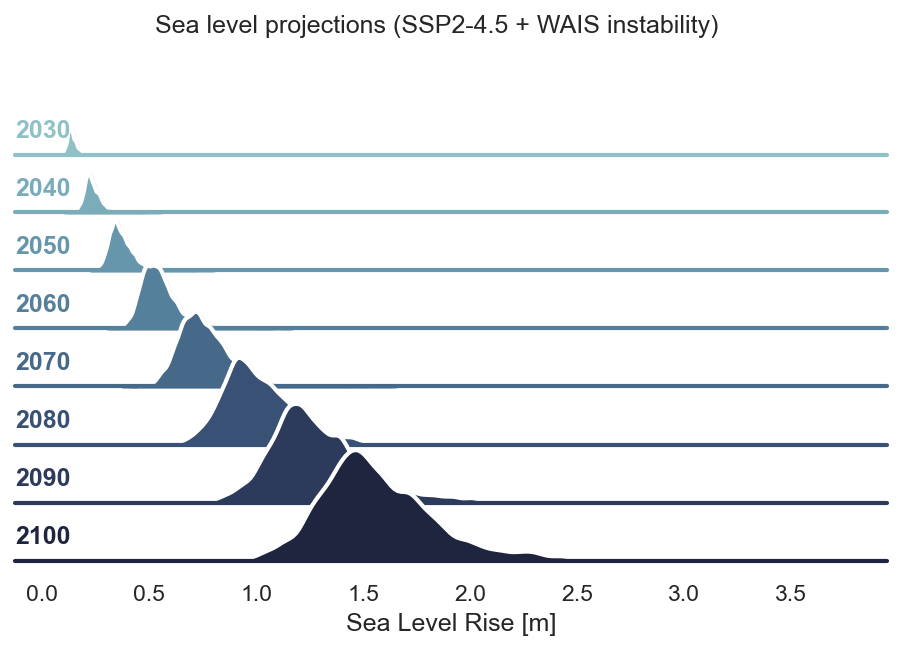

Figure 6 saved.


In [17]:
# ============================================================
# Figure 6: Ridge plot — rate-and-state for user-defined SSPs
# across years, cubehelix color palette.
# Same labels as Figure 2.
# Seaborn FacetGrid ridge plot style with perspective scaling.
# ============================================================

# --- User-adjustable parameters ---
RIDGE6_YEARS = np.arange(2030, 2110, 10)  # default 2025-2100
RIDGE6_SSP = 'SSP2-4.5'
SHOW_IMPACT_POP_6 = False
SHOW_IMPACT_COST_6 = False
SHOW_COMBINED_6 = True        # toggle: use combined R&S + WAIS instability

# Perspective scaling: alpha sets the apparent height of the farthest row
# (2030) relative to the closest row (2100).  alpha=0.25 means the 2030
# KDE appears at 25% of its auto-scaled height; 2100 appears at 100%.
PERSPECTIVE_ALPHA = 0.25

# --- Build sample DataFrame ---
n_ridge6 = 3000
rng6 = np.random.default_rng(303)
ridge6_records = []

rs_df6 = mc_results['scenarios'][RIDGE6_SSP]

# Determine whether to use combined or R&S-only samples
use_combined_6 = SHOW_COMBINED_6

for yr in RIDGE6_YEARS:
    if use_combined_6:
        comb, _, _ = get_combined_samples(
            RIDGE6_SSP, yr, n_samples=n_ridge6, seed=303)
        for v in comb:
            ridge6_records.append({'Year': str(yr), 'SLR': v})
    else:
        idx = np.argmin(np.abs(rs_df6['decimal_year'].values - yr))
        med = rs_df6['gmsl'].values[idx]
        lo = rs_df6['gmsl_lower'].values[idx]
        hi = rs_df6['gmsl_upper'].values[idx]
        sig = (hi - lo) / (2 * 1.645)
        for v in rng6.normal(med, sig, n_ridge6):
            ridge6_records.append({'Year': str(yr), 'SLR': v})

df_ridge6 = pd.DataFrame(ridge6_records)

# Ordered categorical so rows go from earliest (top) to latest (bottom)
year_order = [str(yr) for yr in RIDGE6_YEARS]
df_ridge6['Year'] = pd.Categorical(df_ridge6['Year'], categories=year_order,
                                   ordered=True)

# --- Seaborn FacetGrid ridge plot ---
# Temporarily switch theme for the ridge plot
_prev_style = plt.rcParams.copy()
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

n_yrs6 = len(RIDGE6_YEARS)
pal = sns.cubehelix_palette(n_yrs6, rot=-0.25, light=0.7)

# sharey=False: each row auto-scales its y-axis independently
g = sns.FacetGrid(df_ridge6, row="Year", hue="Year",
                  aspect=15, height=0.5, palette=pal,
                  sharey=False)

# Filled KDE
g.map(sns.kdeplot, "SLR",
      bw_adjust=0.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

# White outline on top
g.map(sns.kdeplot, "SLR",
      clip_on=False, color="w", lw=2, bw_adjust=0.5)

# Baseline reference line
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# --- Perspective scaling ---
# After auto-scaling, adjust each row's y-limits to create a 3D effect:
# later years (close to observer) appear taller, earlier years (far) shorter.
# perspective(i) = alpha + (1 - alpha) * i / (n - 1)
#   i=0 (2030, farthest): ylim expanded by 1/alpha -> KDE appears small
#   i=n-1 (2100, closest): ylim unchanged -> KDE at full height
for i, ax in enumerate(g.axes.flat):
    p = i / max(n_yrs6 - 1, 1)
    perspective = PERSPECTIVE_ALPHA + (1.0 - PERSPECTIVE_ALPHA) * p
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax / perspective)

# Year labels on the left
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "SLR")

# Overlap rows; bottom margin ensures 2100 KDE is not clipped
g.figure.subplots_adjust(hspace=-0.5, bottom=0.05, top=0.92)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# X-axis label on the bottom row only
g.axes[-1, 0].set_xlabel('Sea Level Rise [m]')

# Title -- use figure-level suptitle with minimal padding
title_suffix = ' + WAIS instability' if use_combined_6 else ''
g.figure.suptitle(
    f'Sea level projections ({RIDGE6_SSP}{title_suffix})',
    fontsize=12, y=0.96)

# --- Impact axes on the top row ---
ax_top = g.axes[0, 0]

if SHOW_IMPACT_POP_6:
    ax_pop = ax_top.twiny()
    sl_lo_r, sl_hi_r = ax_top.get_xlim()
    pop_baseline = people_displaced_kulpstrauss2019(0.0)
    pop_ticks_m = np.arange(0.0, sl_hi_r + 0.1, 0.1)
    pop_ticks_m = pop_ticks_m[(pop_ticks_m >= sl_lo_r) & (pop_ticks_m <= sl_hi_r)]
    pop_labels = [f'{people_displaced_kulpstrauss2019(v) - pop_baseline:.0f}'
                  for v in pop_ticks_m]
    ax_pop.set_xlim(sl_lo_r, sl_hi_r)
    ax_pop.set_xticks(pop_ticks_m)
    ax_pop.set_xticklabels(pop_labels, color='#666666', fontsize=7)
    ax_pop.set_xlabel('People At Risk of Displacement [Millions]',
                      color='#666666', fontsize=8)
    ax_pop.tick_params(top=True, length=0)

if SHOW_IMPACT_COST_6:
    ax_cost = ax_top.twiny()
    ax_cost.spines['top'].set_position(('outward', 28))
    sl_lo_r, sl_hi_r = ax_top.get_xlim()
    cost_ticks_m = np.arange(0.0, sl_hi_r + 0.1, 0.1)
    cost_ticks_m = cost_ticks_m[(cost_ticks_m >= sl_lo_r) & (cost_ticks_m <= sl_hi_r)]
    cost_labels = [f'{0.45e-3 * slr_cost_jevrejeva2018(v):.2f}'
                   for v in cost_ticks_m]
    ax_cost.set_xlim(sl_lo_r, sl_hi_r)
    ax_cost.set_xticks(cost_ticks_m)
    ax_cost.set_xticklabels(cost_labels, color='#999999', fontsize=7)
    ax_cost.set_xlabel('Annual Costs [Trillions US\\$]',
                       color='#999999', fontsize=8)
    ax_cost.tick_params(top=True, length=0)

g.figure.savefig('../figures/playing_w_figures_fig6_ridge_cubehelix.png',
                 dpi=200, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

# Restore previous matplotlib style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

In [18]:
# ============================================================
# Figure 7 — IPCC warming-level distributions: computation + KDE
# Shows IPCC SLR at 2100 conditioned on fixed warming levels,
# isolating SLR component uncertainty from SSP warming spread.
# ============================================================

# --- User-adjustable parameters ---
TLIM_YEAR = 2100
N_TLIM = 10000
BW_FACTOR_TLIM = 0.8
TLIM_SEED = 303

WARMING_LEVELS = {
    '1.5°C': 'tlim1p5win0p25',
    '2.0°C': 'tlim2p0win0p25',
    '3.0°C': 'tlim3p0win0p25',
    '4.0°C': 'tlim4p0win0p25',
    '5.0°C': 'tlim5p0win0p25',
}

# --- Load tlim data from HDF5 ---
rng_tlim = np.random.default_rng(TLIM_SEED)

tlim_samples = {}   # {label: array of N_TLIM samples}
tlim_summary = {}   # {label: {median, p5, p95}}

with pd.HDFStore(h5_path, 'r') as store:
    for label, key in WARMING_LEVELS.items():
        df = store[f'/projections/gmsl/{key}']
        idx = np.argmin(np.abs(df['decimal_year'].values - TLIM_YEAR))
        med = df['gmsl'].values[idx]
        lo = df['gmsl_lower'].values[idx]
        hi = df['gmsl_upper'].values[idx]
        sig = (hi - lo) / (2 * 1.645)
        tlim_samples[label] = rng_tlim.normal(med, sig, N_TLIM)
        tlim_summary[label] = {
            'median': float(med), 'p5': float(lo), 'p95': float(hi),
        }

# --- Sequential color palette (cool → warm) ---
from matplotlib.colors import to_hex
_n_wl = len(WARMING_LEVELS)
_cmap = plt.cm.YlOrRd
tlim_palette = {}
for i, label in enumerate(WARMING_LEVELS):
    frac = 0.25 + 0.65 * i / (_n_wl - 1)   # map to 0.25–0.90 range of colormap
    tlim_palette[label] = to_hex(_cmap(frac))

# --- Global x-range and KDE ---
_all = np.concatenate(list(tlim_samples.values()))
tlim_x_lo = float(np.percentile(_all, 0.1)) - 0.02
tlim_x_hi = float(np.percentile(_all, 99.9)) + 0.02
tlim_x_grid = np.linspace(tlim_x_lo, tlim_x_hi, 400)

tlim_kde = {}
for label, samp in tlim_samples.items():
    kde = gaussian_kde(samp, bw_method='scott')
    kde.set_bandwidth(kde.factor * BW_FACTOR_TLIM)
    tlim_kde[label] = kde(tlim_x_grid)

# --- Print summary ---
print(f'IPCC warming-level distributions at {TLIM_YEAR}  (N={N_TLIM}, bw={BW_FACTOR_TLIM})')
print(f'{"Level":>8}  {"Median":>7}  {"90% CI":>16}')
for label, s in tlim_summary.items():
    print(f'{label:>8}  {s["median"]:7.3f}  [{s["p5"]:.3f}, {s["p95"]:.3f}]')

IPCC warming-level distributions at 2100  (N=10000, bw=0.8)
   Level   Median            90% CI
   1.5°C    0.441  [0.278, 0.730]
   2.0°C    0.508  [0.334, 0.849]
   3.0°C    0.613  [0.436, 0.992]
   4.0°C    0.700  [0.520, 1.097]
   5.0°C    0.808  [0.624, 1.262]


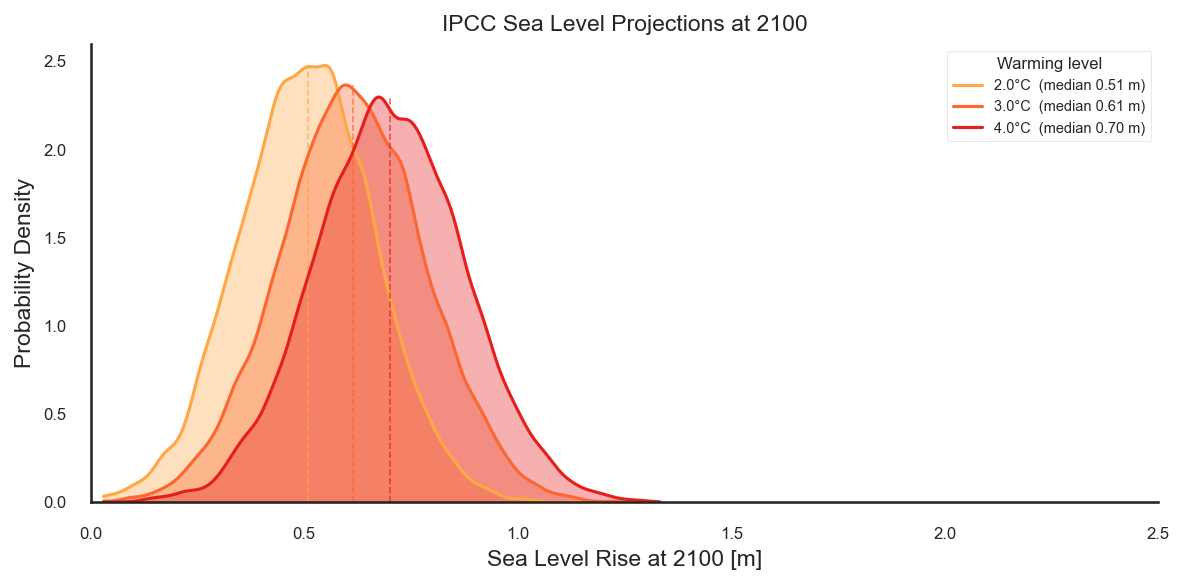

Figure 7 saved.


In [19]:
# ============================================================
# Figure 7: IPCC SLR at 2100 conditioned on warming level
# Plotting only — uses precomputed tlim_kde from the cell above.
# ============================================================
from matplotlib.patches import Patch
from scipy.interpolate import interp1d

# --- User-adjustable PLOT parameters ---
FILL_ALPHA = 0.35
LINE_WIDTH = 1.5
SHOW_MEDIANS = True
SHOW_IMPACT_POP_7 = False
SHOW_IMPACT_COST_7 = False

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 4))

for label in WARMING_LEVELS:
    if not label == '1.5°C' and not label=='5.0°C':
        color = tlim_palette[label]
        density = tlim_kde[label]
        med = tlim_summary[label]['median']
        ax.fill_between(tlim_x_grid, density, alpha=FILL_ALPHA, color=color)
        ax.plot(tlim_x_grid, density, color=color, lw=LINE_WIDTH,
                label=f'{label}  (median {med:.2f} m)')
        if SHOW_MEDIANS:
            peak = density.max()
            ax.vlines(med, 0, peak, color=color, linestyle='--', lw=0.8, alpha=0.7)

ax.set_xlabel('Sea Level Rise at 2100 [m]')
ax.set_ylabel('Probability Density')
ax.set_xlim(0, 2.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=7, frameon=True, framealpha=0.9,
          title='Warming level', title_fontsize=8)
ax.set_title('IPCC Sea Level Projections at 2100',
             fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Impact axes ---
sl_lo_r, sl_hi_r = ax.get_xlim()
slr_test = np.linspace(sl_lo_r, sl_hi_r, 2000)

def _nice_step(val_range, base_unit, target_nticks=6):
    raw_step = val_range / target_nticks
    return max(base_unit, np.round(raw_step / base_unit) * base_unit)

if SHOW_IMPACT_POP_7:
    ax_pop = ax.twiny()
    ax_pop.xaxis.set_ticks_position('bottom')
    ax_pop.xaxis.set_label_position('bottom')
    for sp in ax_pop.spines.values():
        sp.set_visible(False)
    ax_pop.spines['bottom'].set_visible(True)
    ax_pop.spines['bottom'].set_position(('outward', 40))
    ax_pop.spines['bottom'].set_color('#666666')

    pop_baseline = people_displaced_kulpstrauss2019(0.0)
    pop_test = np.array([people_displaced_kulpstrauss2019(v) - pop_baseline
                         for v in slr_test])
    pop_to_slr = interp1d(pop_test, slr_test, bounds_error=False,
                           fill_value='extrapolate')
    pop_max = pop_test.max()
    pop_step = _nice_step(pop_max, base_unit=10)
    pop_targets = np.arange(0, pop_max + pop_step, pop_step)
    pop_targets = pop_targets[pop_targets <= pop_max * 1.05]
    pop_tick_slr = pop_to_slr(pop_targets)
    mask = (pop_tick_slr >= sl_lo_r) & (pop_tick_slr <= sl_hi_r)
    ax_pop.set_xlim(sl_lo_r, sl_hi_r)
    ax_pop.set_xticks(pop_tick_slr[mask])
    ax_pop.set_xticklabels([f'{int(v)}' for v in pop_targets[mask]],
                           color='#666666', fontsize=7)
    ax_pop.set_xlabel('People At Risk of Displacement [Millions]',
                      color='#666666', fontsize=8)
    ax_pop.tick_params(bottom=True, top=False, length=3, colors='#666666')

if SHOW_IMPACT_COST_7:
    ax_cost = ax.twiny()
    ax_cost.xaxis.set_ticks_position('bottom')
    ax_cost.xaxis.set_label_position('bottom')
    for sp in ax_cost.spines.values():
        sp.set_visible(False)
    offset_cost = 70 if SHOW_IMPACT_POP_7 else 40
    ax_cost.spines['bottom'].set_visible(True)
    ax_cost.spines['bottom'].set_position(('outward', offset_cost))
    ax_cost.spines['bottom'].set_color('#999999')

    cost_test = np.array([0.45e-3 * slr_cost_jevrejeva2018(v)
                          for v in slr_test])
    cost_to_slr = interp1d(cost_test, slr_test, bounds_error=False,
                            fill_value='extrapolate')
    cost_max = cost_test.max()
    cost_targets = np.array([0] + list(np.arange(4, cost_max + 2, 2)))
    cost_targets = cost_targets[cost_targets <= cost_max * 1.05]
    cost_tick_slr = cost_to_slr(cost_targets)
    mask = (cost_tick_slr >= sl_lo_r) & (cost_tick_slr <= sl_hi_r)
    ax_cost.set_xlim(sl_lo_r, sl_hi_r)
    ax_cost.set_xticks(cost_tick_slr[mask])
    ax_cost.set_xticklabels([f'{int(v)}' for v in cost_targets[mask]],
                            color='#999999', fontsize=7)
    ax_cost.set_xlabel('Global Annual Costs [Trillions US\\$]',
                       color='#999999', fontsize=8)
    ax_cost.tick_params(bottom=True, top=False, length=3, colors='#999999')

fig.tight_layout()
fig.savefig('../figures/playing_w_figures_fig7_ipcc_warming_levels.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')